In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Options: 0 = all, 1 = filter INFO, 2 = filter WARNING, 3 = ERROR only
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # disable GPU

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set memory growth to True
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

2025-07-11 23:37:40.765328: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752302260.774014  577018 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752302260.776904  577018 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752302260.783383  577018 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752302260.783391  577018 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752302260.783392  577018 computation_placer.cc:177] computation placer alr

In [2]:
!nvidia-smi

Fri Jul 11 23:37:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.77                 Driver Version: 565.77         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...    Off |   00000000:01:00.0  On |                  N/A |
| N/A   42C    P8              3W /  115W |    1788MiB /   8188MiB |     21%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.optimizers import Adam

from IPython.display import display

In [2]:
# Custom callback to stop training after a time limit
class TimeStopping(Callback):
    def __init__(self, max_seconds=300):
        super().__init__()
        self.max_seconds = max_seconds
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        if time.time() - self.start_time > self.max_seconds:
            print(f"\n⏱️ Stopping training - time limit of {self.max_seconds} seconds reached.")
            self.model.stop_training = True

# Evaluation function
def eval_classification(model, X, y, name='model', labels=None):
    preds = np.rint(model.predict(X))
    print(classification_report(y, preds, target_names=labels))

    ConfusionMatrixDisplay.from_predictions(y, preds, display_labels=labels)
    plt.show()

    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()

    score_df = pd.DataFrame(index=[name])
    score_df.loc[name, 'Accuracy'] = accuracy_score(y, preds)
    score_df.loc[name, 'Precision'] = precision_score(y, preds)
    score_df.loc[name, 'Recall'] = recall_score(y, preds)
    score_df.loc[name, 'F1 Score'] = f1_score(y, preds)
    score_df.loc[name, 'FPR'] = fp / (fp + tn)
    score_df.loc[name, 'FNR'] = fn / (fn + tp)

    return score_df

    
# Function to plot training history
def plot_history(history):
    """Takes a keras model learning history and plots each metric"""
    metrics = history.history.keys()
    for metric in metrics:
        if not 'val' in metric:
            plt.plot(history.history[f'{metric}'], label=f'{metric}')
            if f'val_{metric}' in metrics:
                plt.plot(history.history[f'val_{metric}'], label=f'val_{metric}')
            plt.legend()
            plt.title(f'{metric}')
            plt.xlabel('Epochs')
            plt.ylabel(metric.capitalize())
            plt.grid(True)
            plt.show()


### Classification:
To evaluate the model's performance, the F1 Score is used. It is suitable for phishing detection because it strikes a balance between precision and recall, considering both false positives and false negatives, rather than focusing on one aspect alone. Unlike accuracy, it treats imbalanced datasets well and prevents incorrect performance conclusions. By encapsulating both types of error within a single metric, F1 provides a better understanding of the model's performance and confidence.

### Pseudo Code

FOR each layer_config in layer_configs:
  FOR each epoch_count in epochs_list:
    FOR each min_delta in min_deltas:
      FOR each patience_value in patiences:
        Build sequential model
        Add input + hidden layers with relu
        Add sigmoid output layer
        Compile with Adam, binary_crossentropy
        Apply EarlyStopping + TimeStopping
        Train on X_train, validate on X_val
        Evaluate on both sets using F1 Score, Accuracy, Precision, Recall
        If best F1, save model and config


In [3]:
df_train = pd.read_csv('Split_Data/Model_Ready/train.csv')
df_train.head()
# Define X and y and train data
X_train = df_train.drop(columns = 'label')
y_train = df_train['label']

df_val = pd.read_csv('Split_Data/Model_Ready/val.csv')

# Define X and y and train data
X_val = df_val.drop(columns = 'label')
y_val = df_val['label']

### Build de Model

In [4]:
# ---------------------------------------------------------
# Define hyperparameter search space for grid search
# ---------------------------------------------------------

# Each entry in `layer_configs` is a list representing the number of neurons in each hidden layer
layer_configs = [[64], [128, 64], [256, 128, 64]]

# Number of epochs (maximum) to allow during training
epochs_list = [50, 100]

# Minimum change in validation loss to qualify as an improvement
# Used by the EarlyStopping callback to determine convergence
min_deltas = [0.0, 0.001]

# Number of epochs to wait after no improvement before stopping early
patiences = [1, 3, 5]

# ---------------------------------------------------------
# Initialize tracking variables to record the best model run
# ---------------------------------------------------------

# Collect all evaluation metrics (train/val scores) across all configurations
all_scores = []

# Best F1 score seen so far (used to determine the top-performing model)
best_f1 = -1

# Store the best Keras model instance
best_model = None

# Store the training history of the best model (for plotting)
best_history = None

# Store the hyperparameter configuration of the best model
best_config = None


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-07-12 09:43:43.963450: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2025-07-12 09:43:43.963510: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 128.00 GB
2025-07-12 09:43:43.963519: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 48.00 GB
I0000 00:00:1752338623.963583 8902644 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1752338623.963651 8902644 pluggable_device_


Config: layers=[64], epochs=50, min_delta=0.0, patience=1
Epoch 1/50


2025-07-12 09:43:44.568533: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1650/1650 - 10s - 6ms/step - accuracy: 0.9471 - loss: 0.1494 - val_accuracy: 0.9548 - val_loss: 0.1242
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9552 - loss: 0.1256 - val_accuracy: 0.9575 - val_loss: 0.1216
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9568 - loss: 0.1231 - val_accuracy: 0.9576 - val_loss: 0.1242
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.1216, stopped at epoch 3

Print History


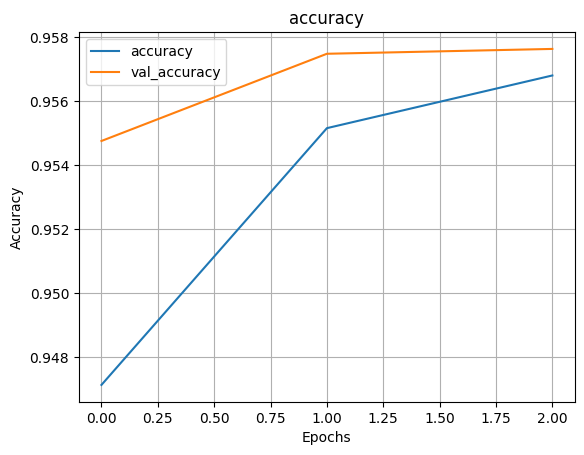

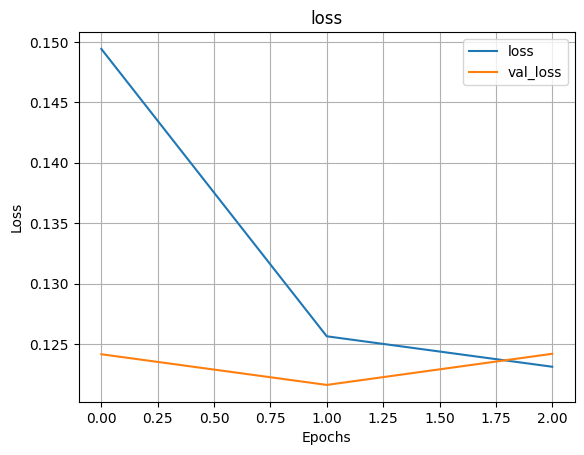

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 643us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



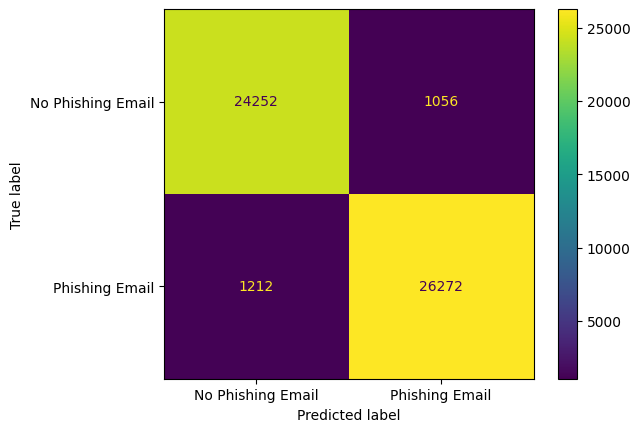

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.96      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



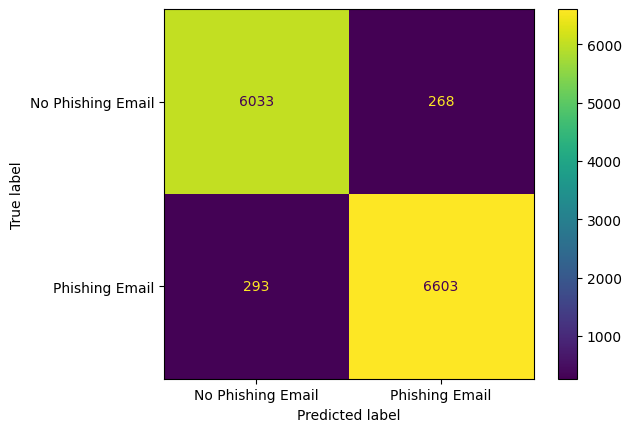


Config: layers=[64], epochs=50, min_delta=0.0, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9503 - loss: 0.1387 - val_accuracy: 0.9607 - val_loss: 0.1203
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1247 - val_accuracy: 0.9554 - val_loss: 0.1255
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9566 - loss: 0.1243 - val_accuracy: 0.9496 - val_loss: 0.1388
Epoch 4/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1241 - val_accuracy: 0.9578 - val_loss: 0.1276
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1203, stopped at epoch 4

Print History


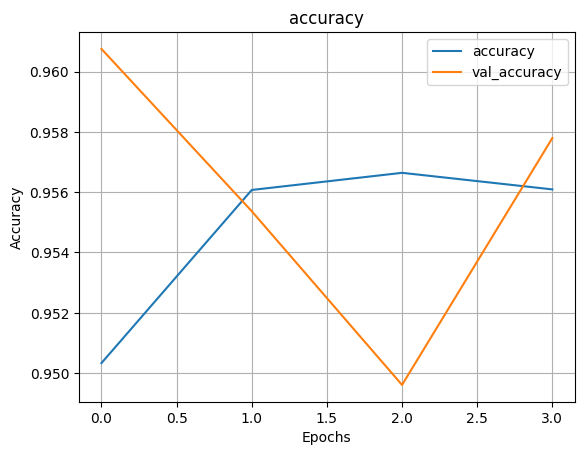

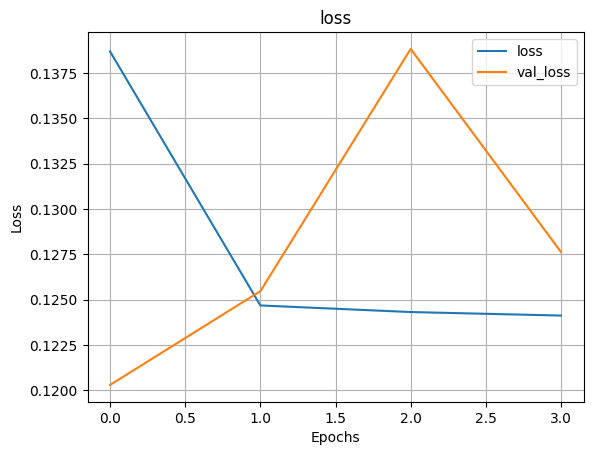

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 627us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



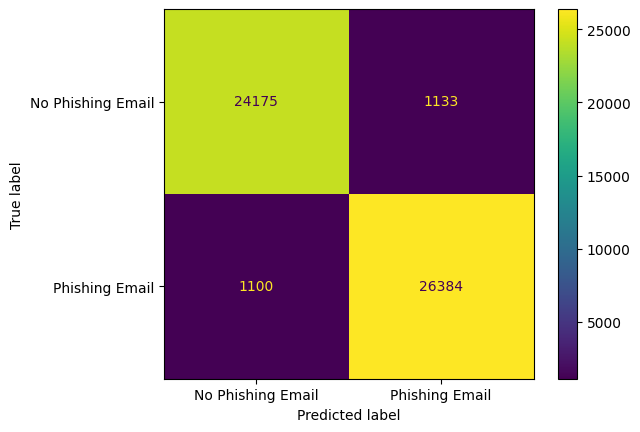

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96      6301
   Phishing Email       0.96      0.97      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



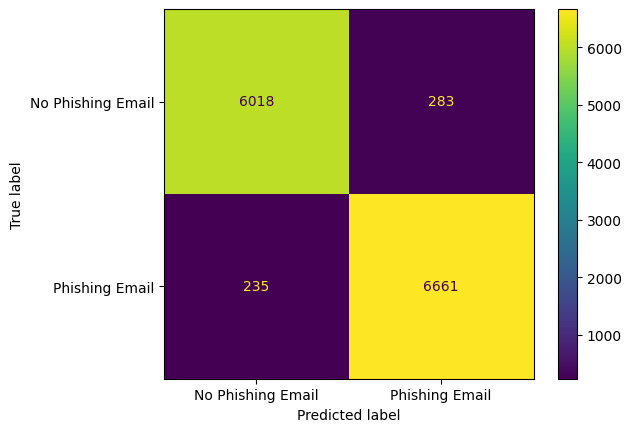


Config: layers=[64], epochs=50, min_delta=0.0, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9477 - loss: 0.1445 - val_accuracy: 0.9591 - val_loss: 0.1220
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9564 - loss: 0.1255 - val_accuracy: 0.9546 - val_loss: 0.1310
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9563 - loss: 0.1261 - val_accuracy: 0.9593 - val_loss: 0.1185
Epoch 4/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9558 - loss: 0.1257 - val_accuracy: 0.9475 - val_loss: 0.2250
Epoch 5/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9551 - loss: 0.1285 - val_accuracy: 0.9550 - val_loss: 0.1299
Epoch 6/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1262 - val_accuracy: 0.9568 - val_loss: 0.1242
Epoch 7/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9553 - loss: 0.1306 - val_accuracy: 0.9526 - val_loss: 0.1306
Epoch 8/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9548 - loss: 0.1284 - val_accuracy: 0.9590 - val_loss: 0.1219
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=

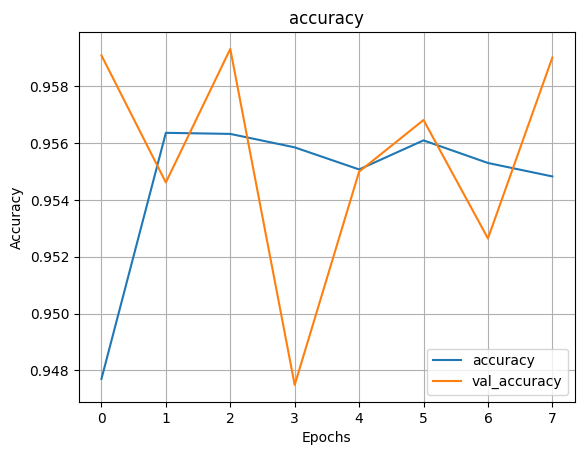

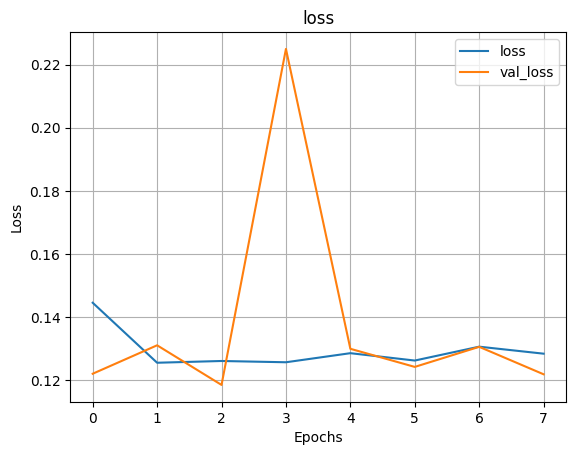

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 689us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



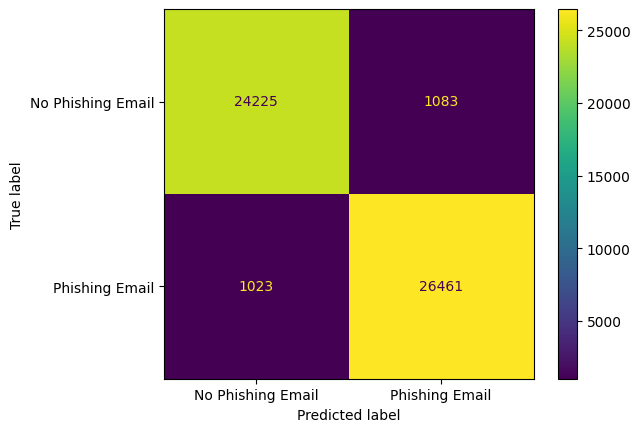

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.97      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



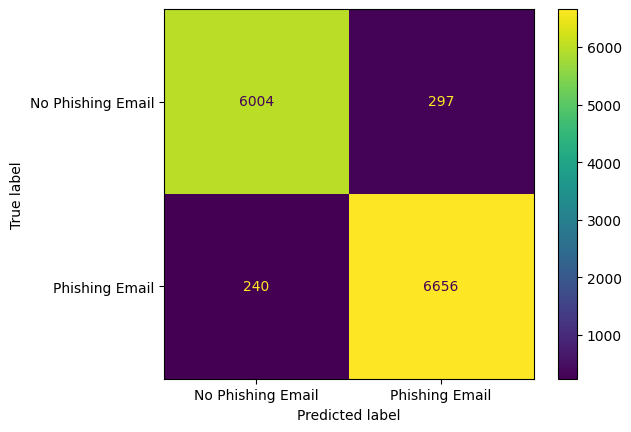


Config: layers=[64], epochs=50, min_delta=0.001, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9438 - loss: 0.1609 - val_accuracy: 0.9588 - val_loss: 0.1190
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9554 - loss: 0.1277 - val_accuracy: 0.9562 - val_loss: 0.1264
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1190, stopped at epoch 2

Print History


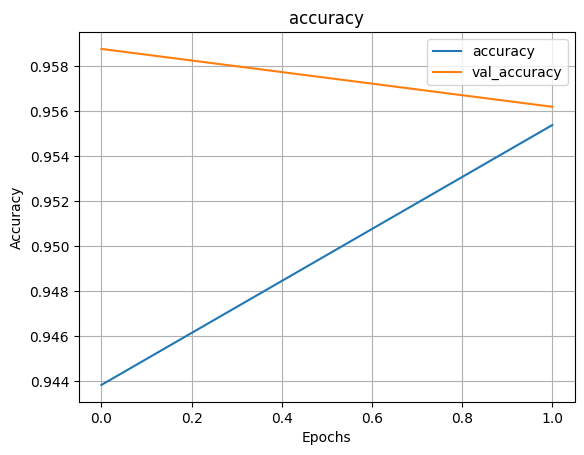

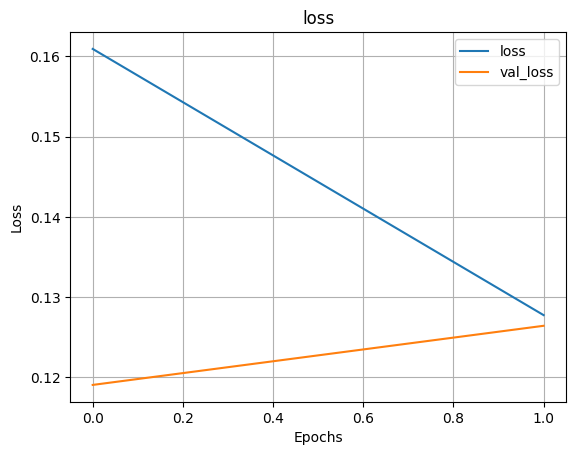

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 634us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



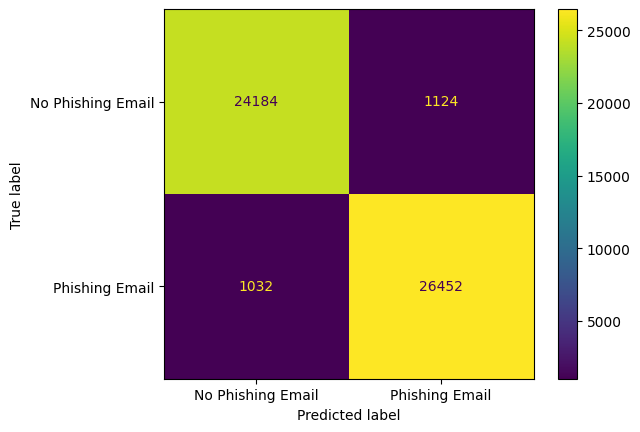

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.97      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



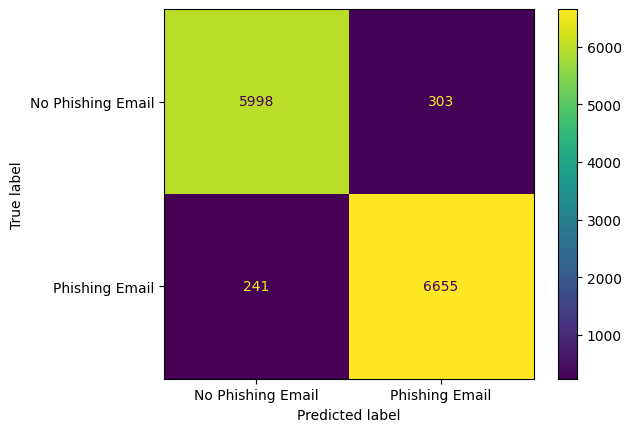


Config: layers=[64], epochs=50, min_delta=0.001, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9484 - loss: 0.1458 - val_accuracy: 0.9502 - val_loss: 0.1401
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9550 - loss: 0.1269 - val_accuracy: 0.9567 - val_loss: 0.1268
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9556 - loss: 0.1264 - val_accuracy: 0.9585 - val_loss: 0.1211
Epoch 4/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9553 - loss: 0.1269 - val_accuracy: 0.9599 - val_loss: 0.1230
Epoch 5/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9557 - loss: 0.1272 - val_accuracy: 0.9581 - val_loss: 0.1215
Epoch 6/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9559 - loss: 0.1291 - val_accuracy: 0.9587 - val_loss: 0.1218
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.1211, stopped at epoch 6

Print History


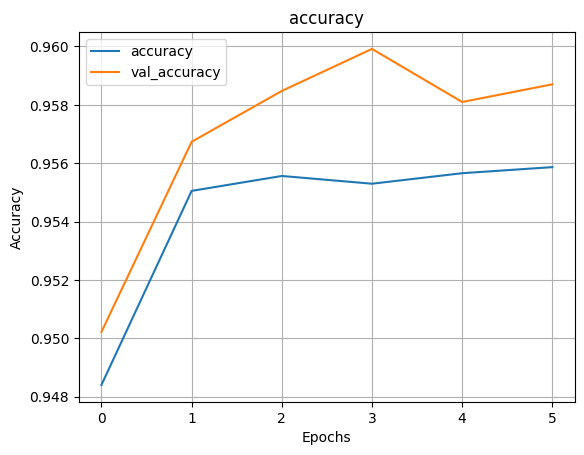

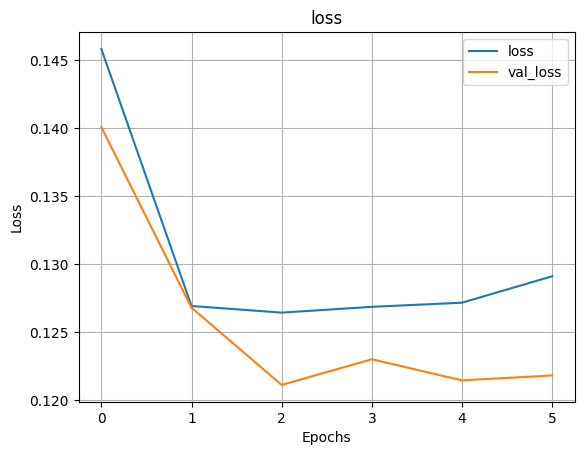

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



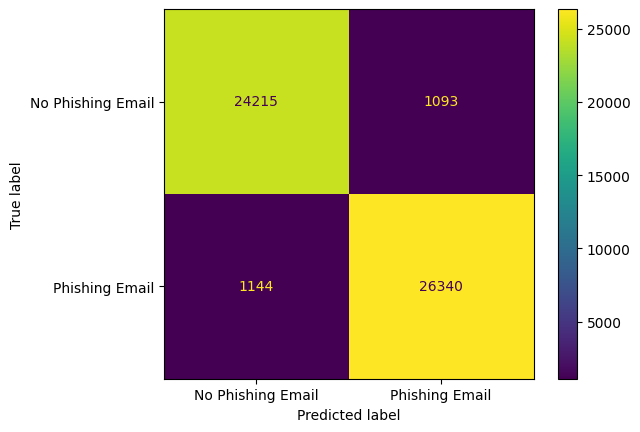

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



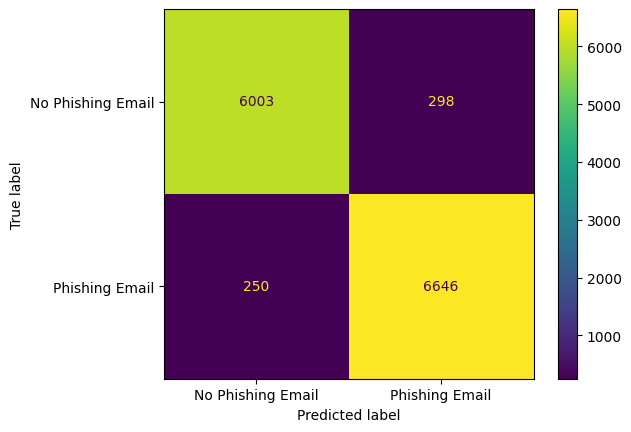


Config: layers=[64], epochs=50, min_delta=0.001, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9467 - loss: 0.1468 - val_accuracy: 0.9551 - val_loss: 0.1251
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9558 - loss: 0.1270 - val_accuracy: 0.9567 - val_loss: 0.1229
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1253 - val_accuracy: 0.9548 - val_loss: 0.1337
Epoch 4/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9556 - loss: 0.1273 - val_accuracy: 0.9576 - val_loss: 0.1197
Epoch 5/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9560 - loss: 0.1265 - val_accuracy: 0.9490 - val_loss: 0.2280
Epoch 6/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9540 - loss: 0.1272 - val_accuracy: 0.9582 - val_loss: 0.1252
Epoch 7/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9552 - loss: 0.1306 - val_accuracy: 0.9567 - val_loss: 0.1273
Epoch 8/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9551 - loss: 0.1309 - val_accuracy: 0.9577 - val_loss: 0.1397
Epoch 9/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9543 - loss: 0.1310 - val_accuracy: 0.9551 - val_loss: 0

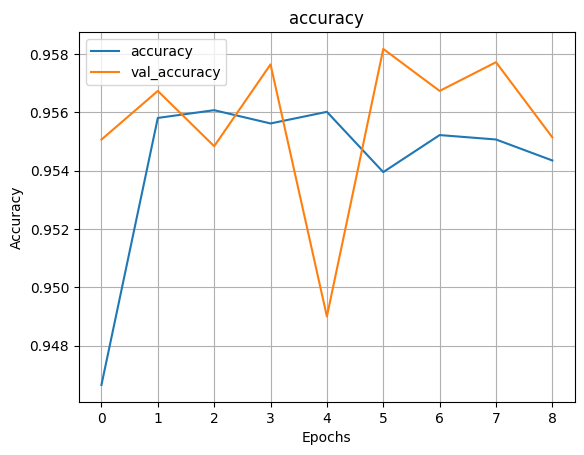

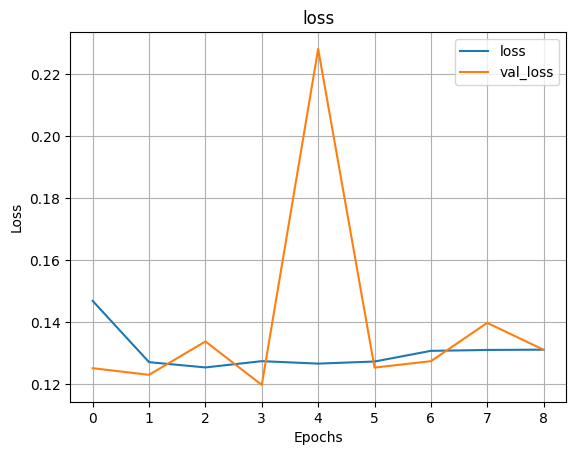

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 632us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



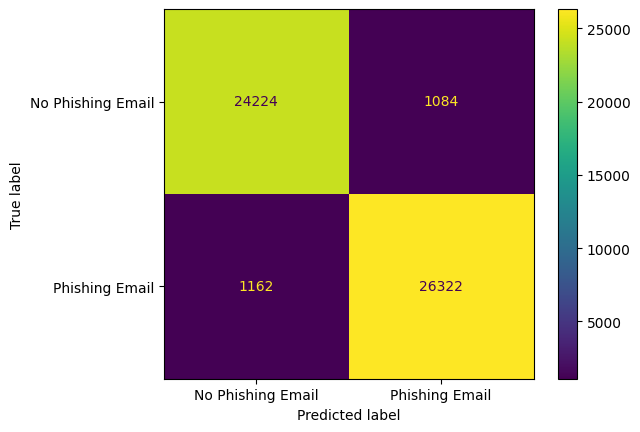

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.96      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



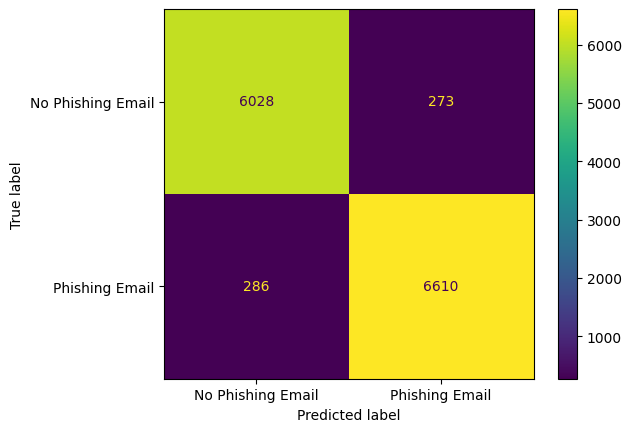


Config: layers=[64], epochs=100, min_delta=0.0, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9483 - loss: 0.1429 - val_accuracy: 0.9557 - val_loss: 0.1275
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9556 - loss: 0.1245 - val_accuracy: 0.9560 - val_loss: 0.1282
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1275, stopped at epoch 2

Print History


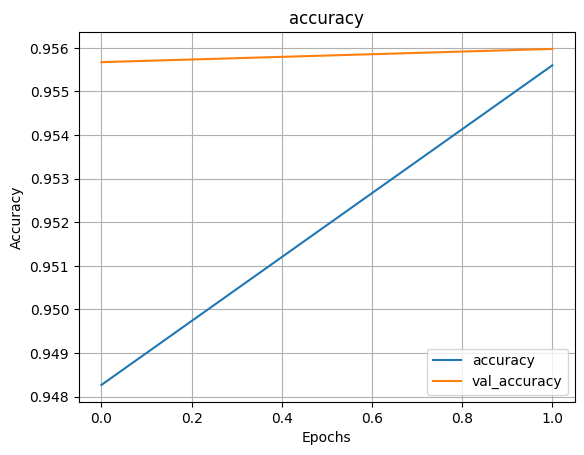

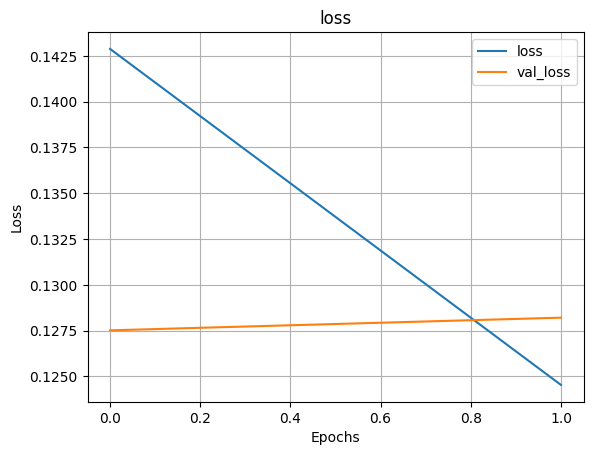

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 639us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.96      0.95     25308
   Phishing Email       0.96      0.95      0.96     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.96      0.95     52792
     weighted avg       0.96      0.95      0.95     52792



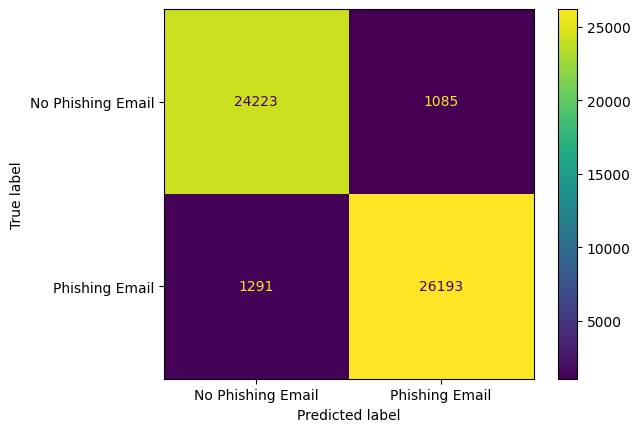

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.96      0.95      6301
   Phishing Email       0.96      0.95      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



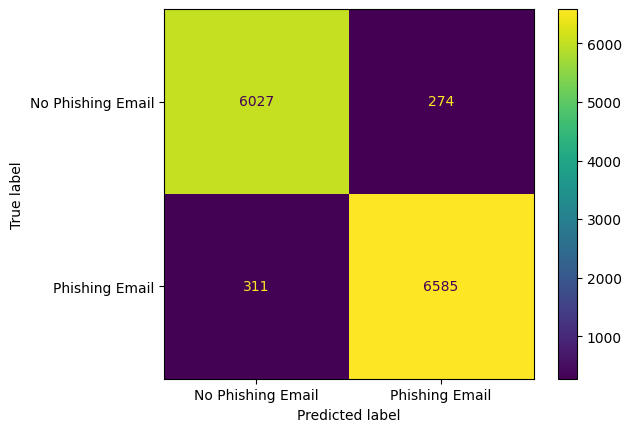


Config: layers=[64], epochs=100, min_delta=0.0, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9450 - loss: 0.1574 - val_accuracy: 0.9574 - val_loss: 0.1246
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9556 - loss: 0.1270 - val_accuracy: 0.9565 - val_loss: 0.1263
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9563 - loss: 0.1260 - val_accuracy: 0.9577 - val_loss: 0.1213
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9557 - loss: 0.1263 - val_accuracy: 0.9596 - val_loss: 0.1191
Epoch 5/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1258 - val_accuracy: 0.9564 - val_loss: 0.1278
Epoch 6/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9560 - loss: 0.1271 - val_accuracy: 0.9552 - val_loss: 0.1256
Epoch 7/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9564 - loss: 0.1267 - val_accuracy: 0.9592 - val_loss: 0.1218
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
Finished. Best val_loss=0.1191, stopped at epoch 7

Print History


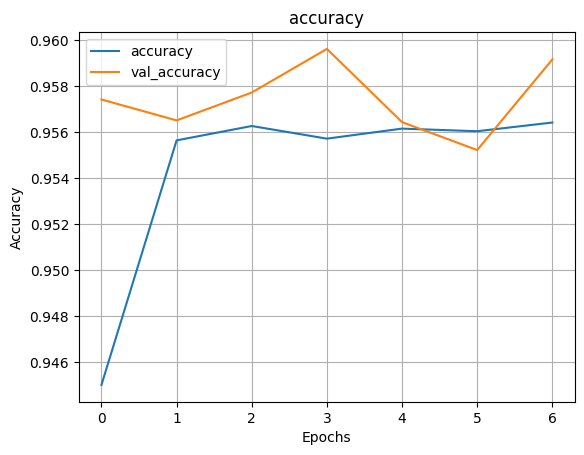

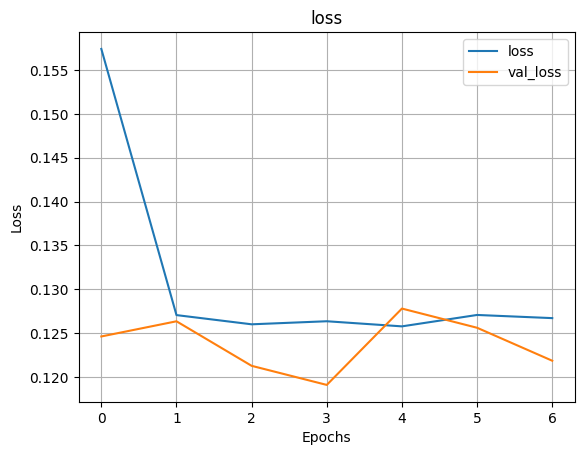

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 633us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



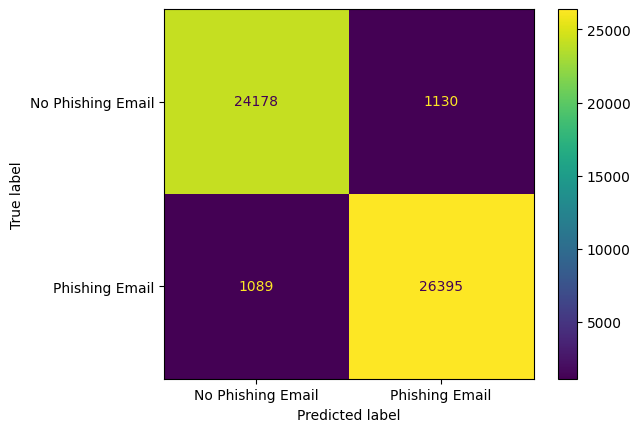

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



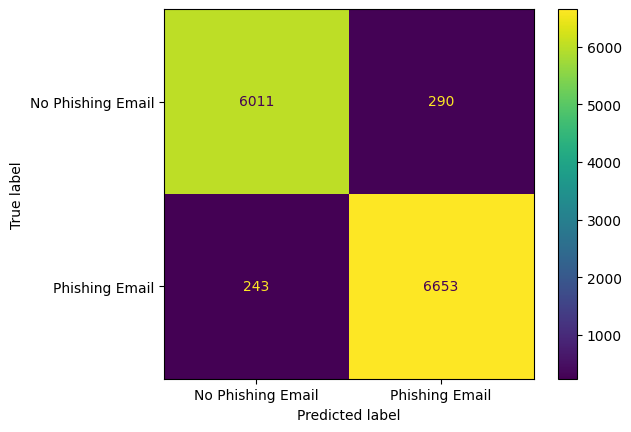


Config: layers=[64], epochs=100, min_delta=0.0, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9489 - loss: 0.1422 - val_accuracy: 0.9489 - val_loss: 0.1480
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9554 - loss: 0.1281 - val_accuracy: 0.9404 - val_loss: 0.2714
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9558 - loss: 0.1282 - val_accuracy: 0.9527 - val_loss: 0.1370
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9557 - loss: 0.1281 - val_accuracy: 0.9543 - val_loss: 0.1276
Epoch 5/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9546 - loss: 0.1270 - val_accuracy: 0.9608 - val_loss: 0.1238
Epoch 6/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9557 - loss: 0.1284 - val_accuracy: 0.9576 - val_loss: 0.1221
Epoch 7/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9553 - loss: 0.1295 - val_accuracy: 0.9592 - val_loss: 0.1210
Epoch 8/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9553 - loss: 0.1297 - val_accuracy: 0.9481 - val_loss: 0.1426
Epoch 9/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9555 - loss: 0.1284 - val_accuracy: 0.9554 - val

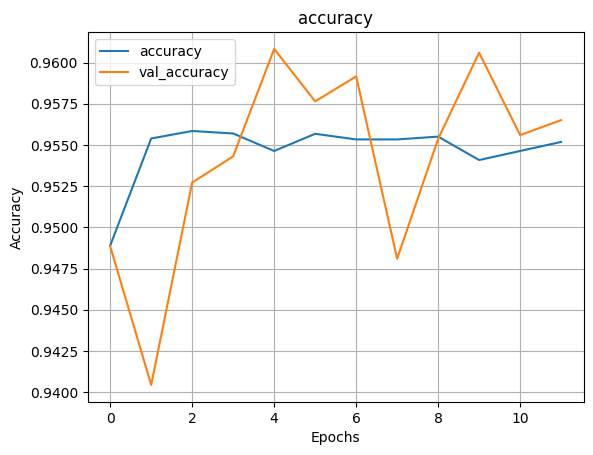

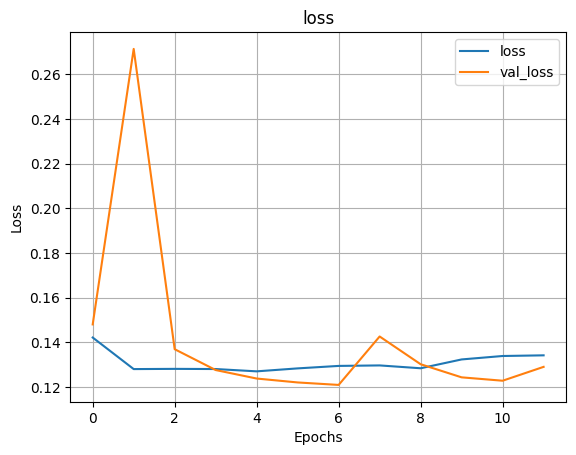

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.95     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



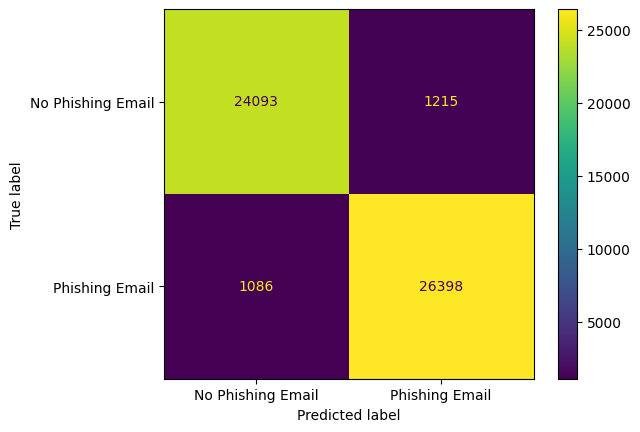

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 644us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



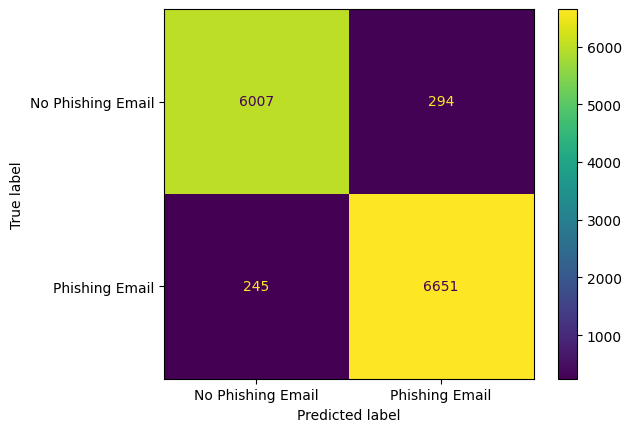


Config: layers=[64], epochs=100, min_delta=0.001, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9477 - loss: 0.1476 - val_accuracy: 0.9558 - val_loss: 0.1278
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9553 - loss: 0.1280 - val_accuracy: 0.9573 - val_loss: 0.1226
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9560 - loss: 0.1257 - val_accuracy: 0.9595 - val_loss: 0.1186
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9559 - loss: 0.1259 - val_accuracy: 0.9596 - val_loss: 0.1210
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.1186, stopped at epoch 4

Print History


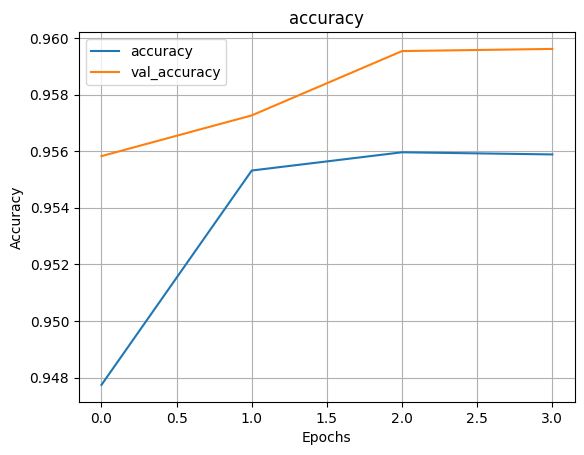

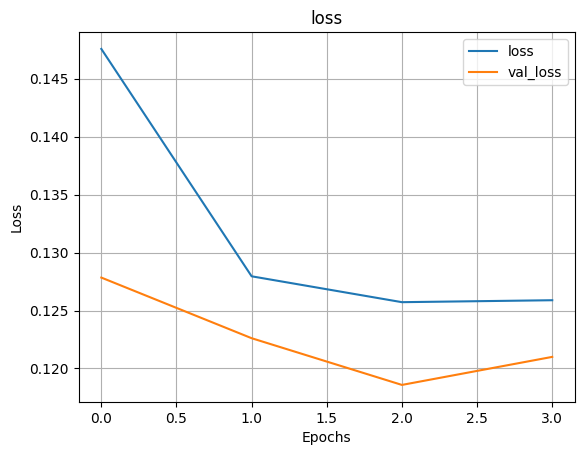

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 635us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



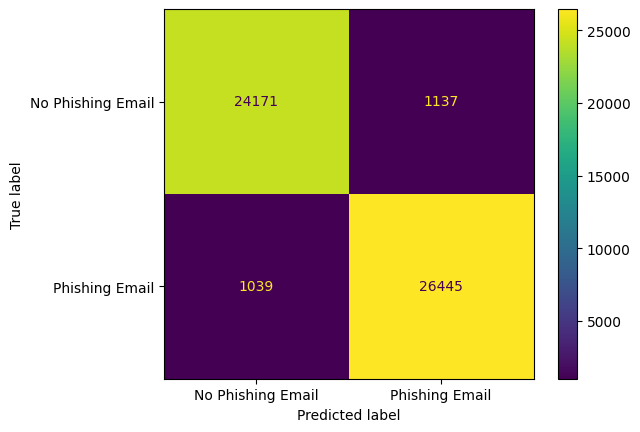

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.97      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



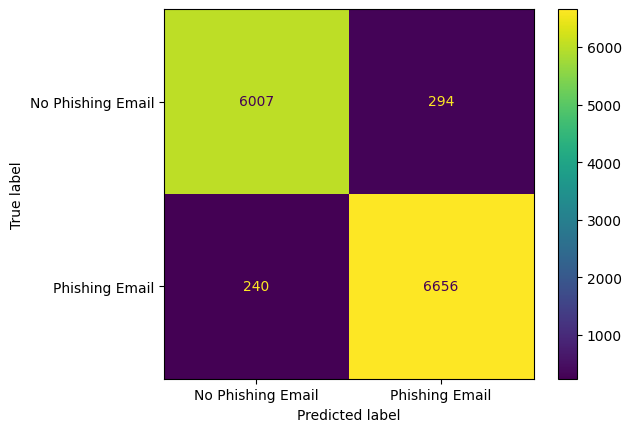


Config: layers=[64], epochs=100, min_delta=0.001, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9469 - loss: 0.1468 - val_accuracy: 0.9582 - val_loss: 0.1232
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9558 - loss: 0.1265 - val_accuracy: 0.9573 - val_loss: 0.1235
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9556 - loss: 0.1255 - val_accuracy: 0.9568 - val_loss: 0.1233
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9557 - loss: 0.1265 - val_accuracy: 0.9584 - val_loss: 0.1183
Epoch 5/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9556 - loss: 0.1287 - val_accuracy: 0.9587 - val_loss: 0.1196
Epoch 6/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9568 - loss: 0.1265 - val_accuracy: 0.9573 - val_loss: 0.1268
Epoch 7/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9551 - loss: 0.1278 - val_accuracy: 0.9603 - val_loss: 0.1214
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
Finished. Best val_loss=0.1183, stopped at epoch 7

Print History


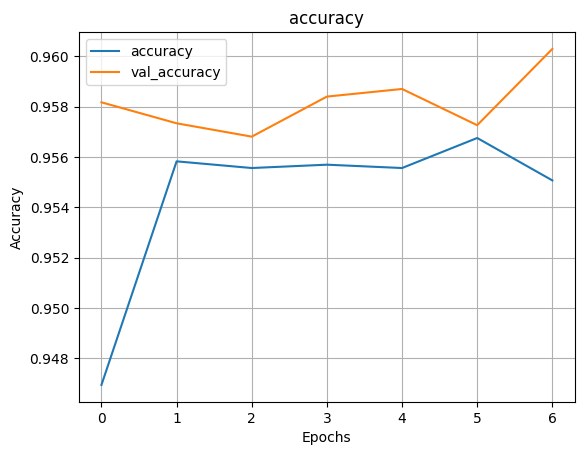

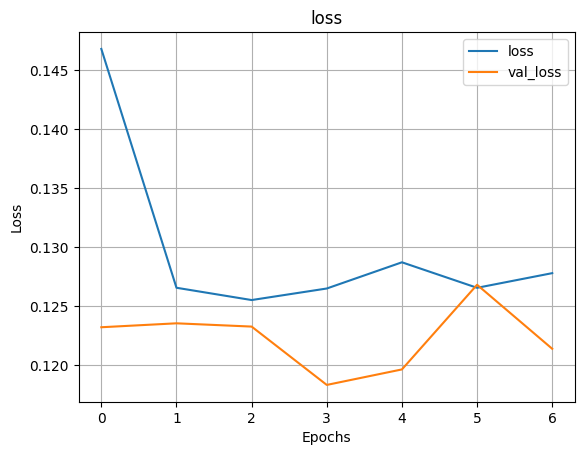

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 628us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



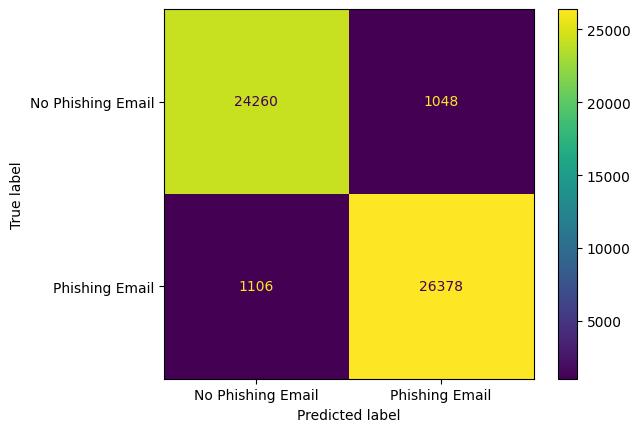

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



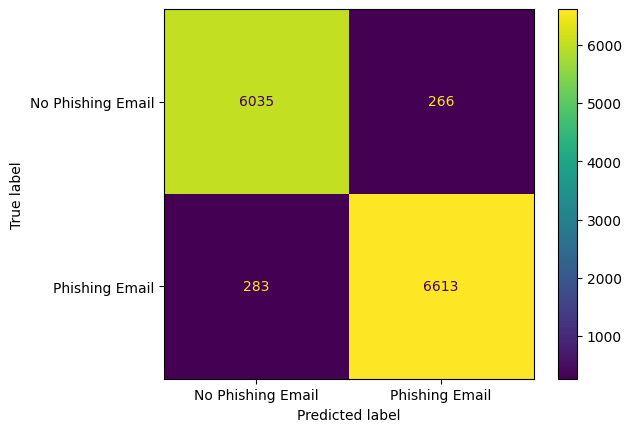


Config: layers=[64], epochs=100, min_delta=0.001, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9487 - loss: 0.1437 - val_accuracy: 0.9545 - val_loss: 0.1291
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9556 - loss: 0.1253 - val_accuracy: 0.9573 - val_loss: 0.1230
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9556 - loss: 0.1260 - val_accuracy: 0.9545 - val_loss: 0.1333
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9558 - loss: 0.1254 - val_accuracy: 0.9586 - val_loss: 0.1218
Epoch 5/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9548 - loss: 0.1285 - val_accuracy: 0.9561 - val_loss: 0.1243
Epoch 6/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1256 - val_accuracy: 0.9598 - val_loss: 0.1234
Epoch 7/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9559 - loss: 0.1286 - val_accuracy: 0.9585 - val_loss: 0.1192
Epoch 8/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9549 - loss: 0.1315 - val_accuracy: 0.9567 - val_loss: 0.1269
Epoch 9/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9547 - loss: 0.1315 - val_accuracy: 0.9578 - val

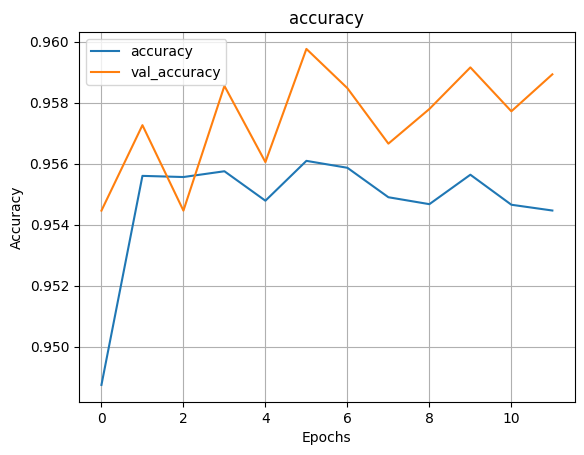

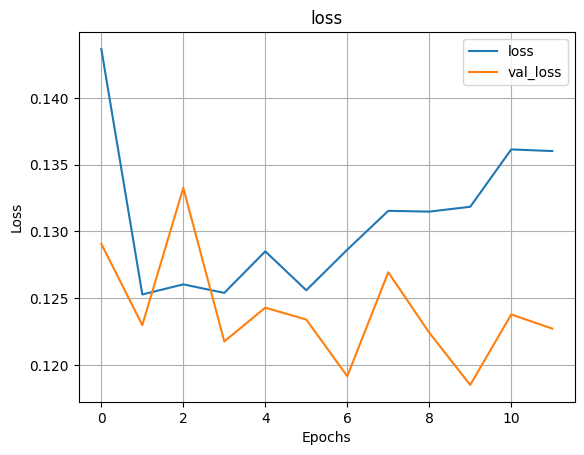

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 627us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



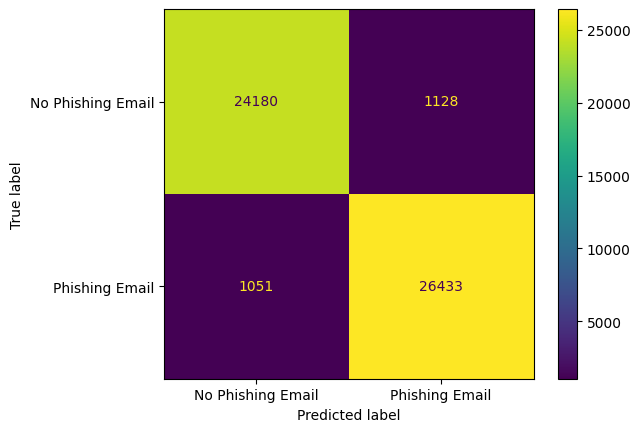

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



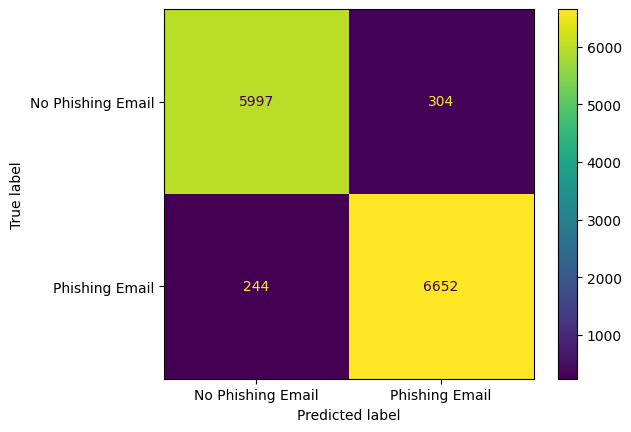


Config: layers=[128, 64], epochs=50, min_delta=0.0, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9402 - loss: 0.1922 - val_accuracy: 0.9019 - val_loss: 0.4498
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9291 - loss: 0.5535 - val_accuracy: 0.9480 - val_loss: 0.5301
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.4498, stopped at epoch 2

Print History


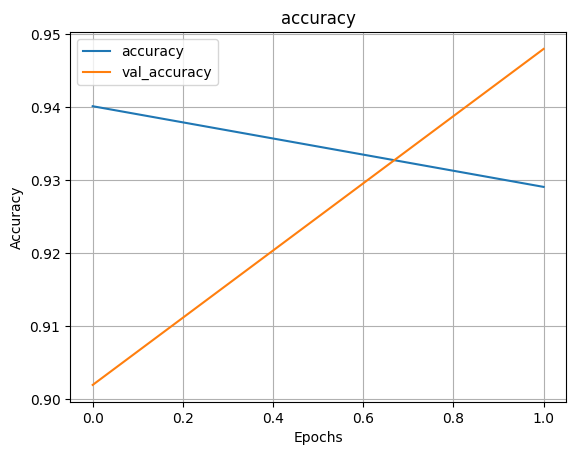

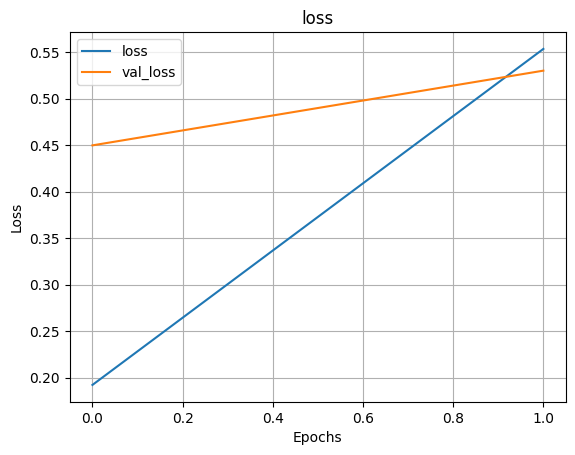

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 656us/step
                   precision    recall  f1-score   support

No Phishing Email       0.91      0.89      0.90     25308
   Phishing Email       0.90      0.91      0.91     27484

         accuracy                           0.90     52792
        macro avg       0.90      0.90      0.90     52792
     weighted avg       0.90      0.90      0.90     52792



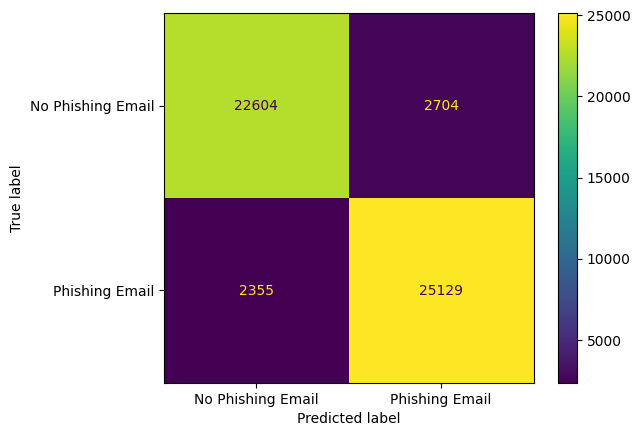

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step
                   precision    recall  f1-score   support

No Phishing Email       0.90      0.89      0.90      6301
   Phishing Email       0.90      0.91      0.91      6896

         accuracy                           0.90     13197
        macro avg       0.90      0.90      0.90     13197
     weighted avg       0.90      0.90      0.90     13197



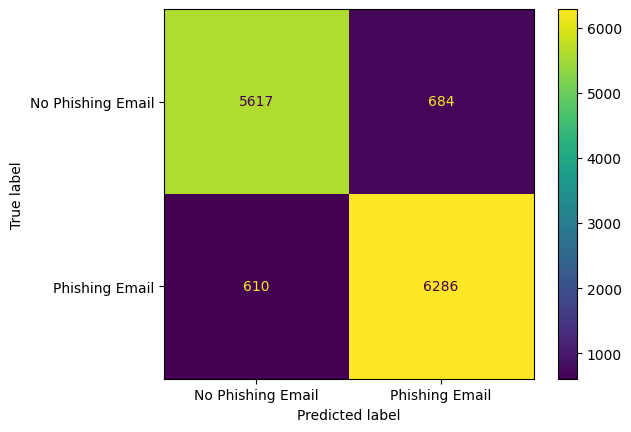


Config: layers=[128, 64], epochs=50, min_delta=0.0, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9381 - loss: 0.2026 - val_accuracy: 0.9350 - val_loss: 0.2761
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9273 - loss: 0.4771 - val_accuracy: 0.9409 - val_loss: 0.4623
Epoch 3/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9202 - loss: 1.2588 - val_accuracy: 0.8181 - val_loss: 6.5141
Epoch 4/50
1650/1650 - 9s - 5ms/step - accuracy: 0.9269 - loss: 1.9918 - val_accuracy: 0.9525 - val_loss: 1.1134
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.2761, stopped at epoch 4

Print History


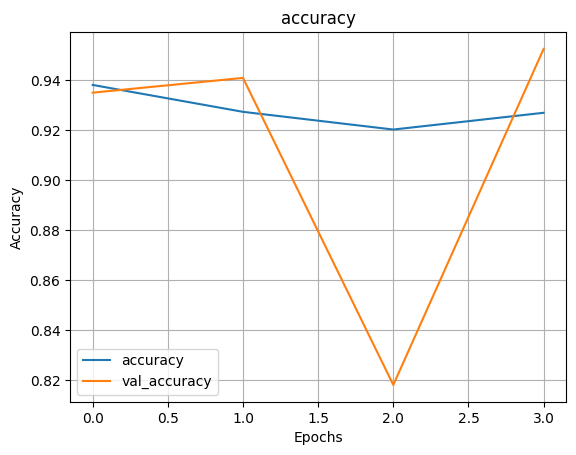

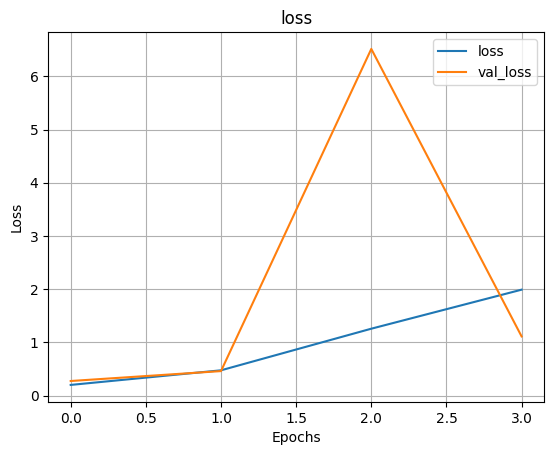

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 654us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.92      0.93     25308
   Phishing Email       0.92      0.94      0.93     27484

         accuracy                           0.93     52792
        macro avg       0.93      0.93      0.93     52792
     weighted avg       0.93      0.93      0.93     52792



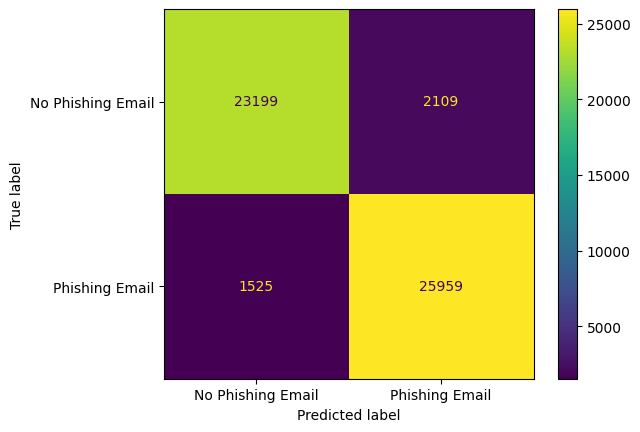

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.92      0.93      6301
   Phishing Email       0.93      0.95      0.94      6896

         accuracy                           0.93     13197
        macro avg       0.94      0.93      0.93     13197
     weighted avg       0.94      0.93      0.93     13197



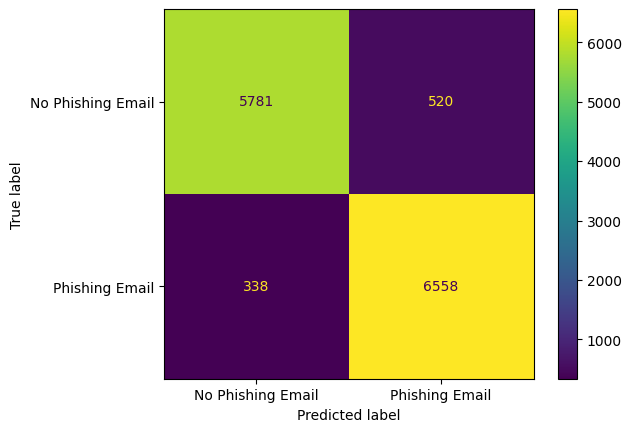


Config: layers=[128, 64], epochs=50, min_delta=0.0, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9418 - loss: 0.1787 - val_accuracy: 0.9248 - val_loss: 0.2938
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9319 - loss: 0.3613 - val_accuracy: 0.9448 - val_loss: 0.3141
Epoch 3/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9245 - loss: 0.8427 - val_accuracy: 0.8792 - val_loss: 1.7355
Epoch 4/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9222 - loss: 1.3921 - val_accuracy: 0.9467 - val_loss: 0.9310
Epoch 5/50
1650/1650 - 9s - 5ms/step - accuracy: 0.9216 - loss: 2.1773 - val_accuracy: 0.9556 - val_loss: 1.0992
Epoch 6/50
1650/1650 - 9s - 5ms/step - accuracy: 0.9216 - loss: 2.7110 - val_accuracy: 0.9378 - val_loss: 2.2187
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.2938, stopped at epoch 6

Print History


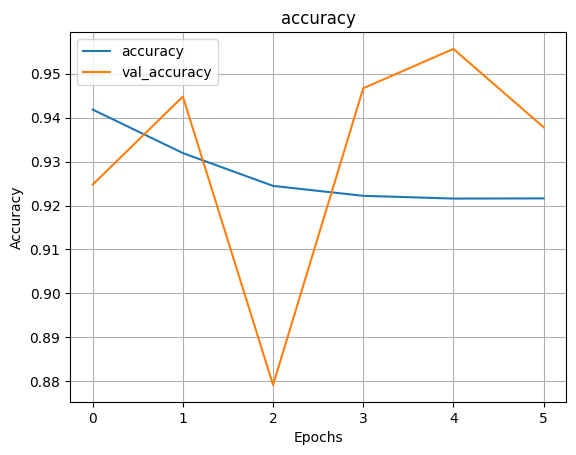

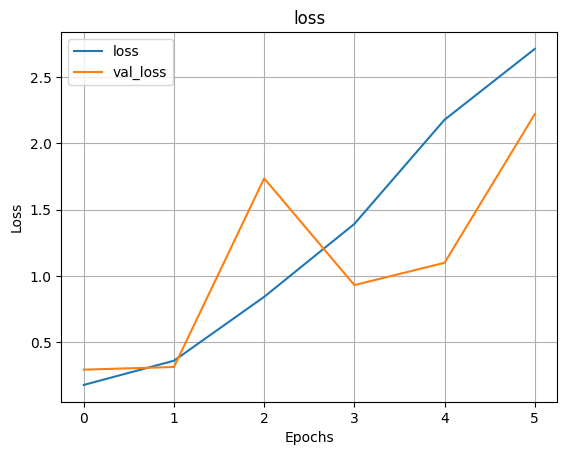

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 654us/step
                   precision    recall  f1-score   support

No Phishing Email       0.92      0.92      0.92     25308
   Phishing Email       0.93      0.93      0.93     27484

         accuracy                           0.93     52792
        macro avg       0.93      0.93      0.93     52792
     weighted avg       0.93      0.93      0.93     52792



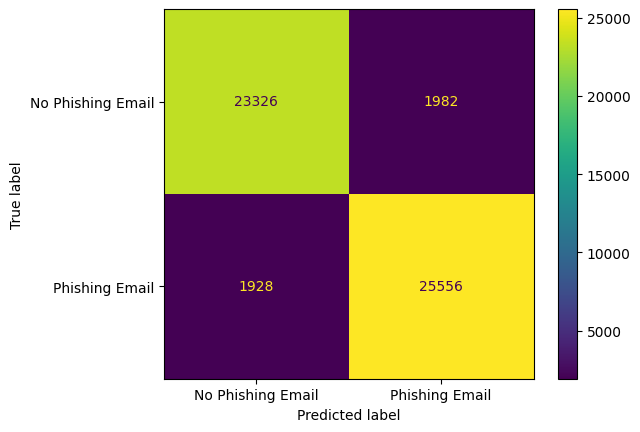

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step
                   precision    recall  f1-score   support

No Phishing Email       0.92      0.92      0.92      6301
   Phishing Email       0.93      0.93      0.93      6896

         accuracy                           0.92     13197
        macro avg       0.92      0.92      0.92     13197
     weighted avg       0.92      0.92      0.92     13197



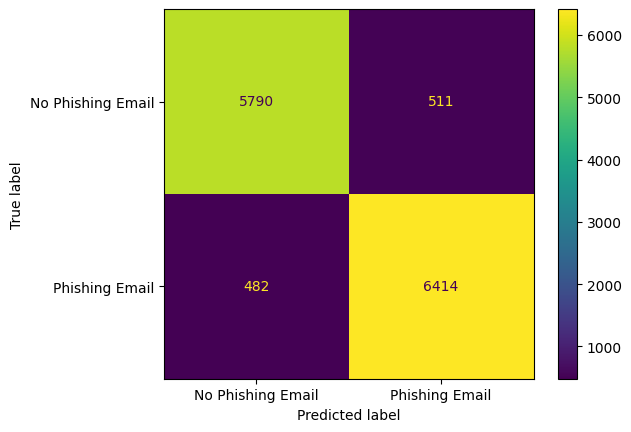


Config: layers=[128, 64], epochs=50, min_delta=0.001, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9422 - loss: 0.1782 - val_accuracy: 0.9551 - val_loss: 0.1541
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9312 - loss: 0.4194 - val_accuracy: 0.8894 - val_loss: 1.1445
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1541, stopped at epoch 2

Print History


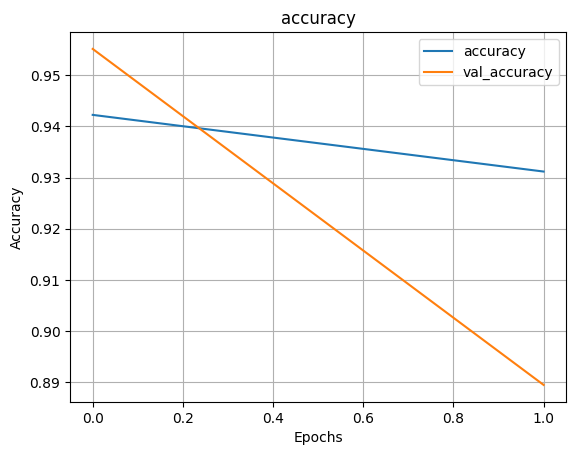

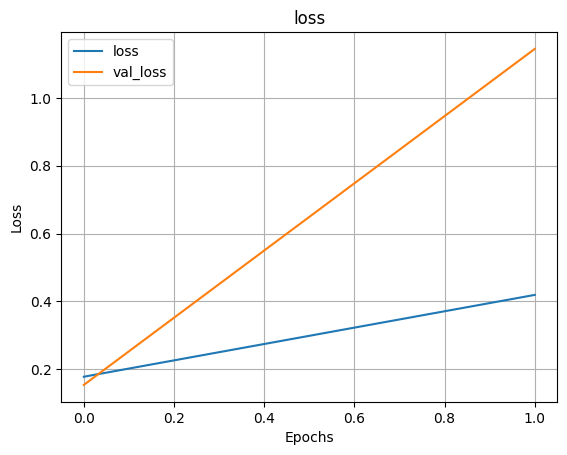

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 660us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.94      0.95     25308
   Phishing Email       0.95      0.97      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



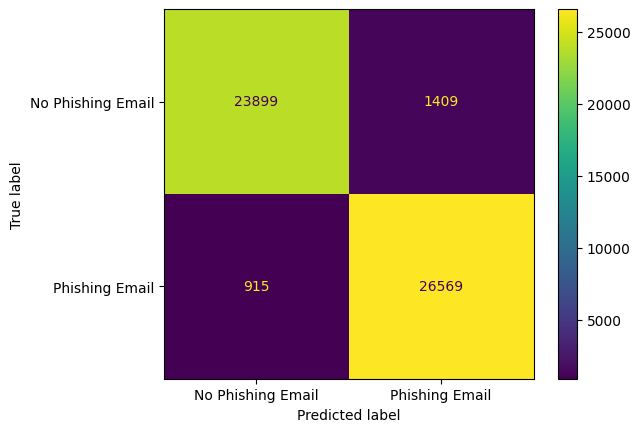

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step
                   precision    recall  f1-score   support

No Phishing Email       0.97      0.94      0.95      6301
   Phishing Email       0.95      0.97      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.95      0.95     13197
     weighted avg       0.96      0.96      0.96     13197



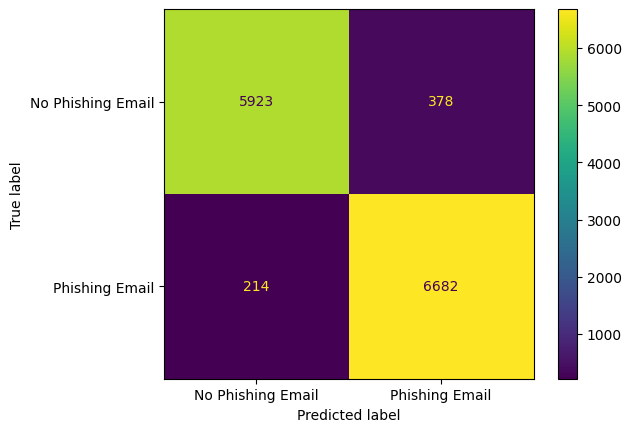


Config: layers=[128, 64], epochs=50, min_delta=0.001, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9397 - loss: 0.1841 - val_accuracy: 0.9512 - val_loss: 0.1768
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9306 - loss: 0.4357 - val_accuracy: 0.9520 - val_loss: 0.3805
Epoch 3/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9262 - loss: 0.9748 - val_accuracy: 0.9554 - val_loss: 0.6047
Epoch 4/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9265 - loss: 1.6016 - val_accuracy: 0.9443 - val_loss: 1.3597
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1768, stopped at epoch 4

Print History


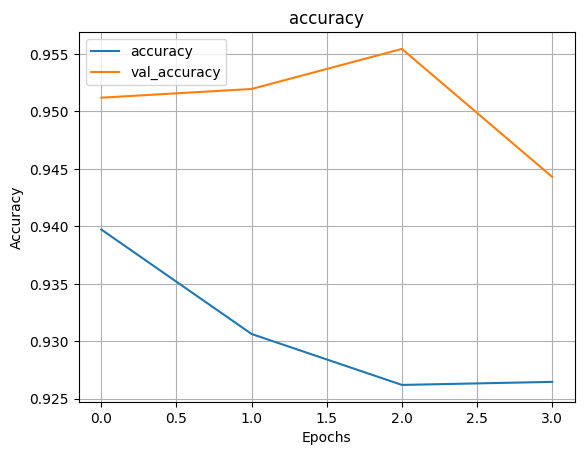

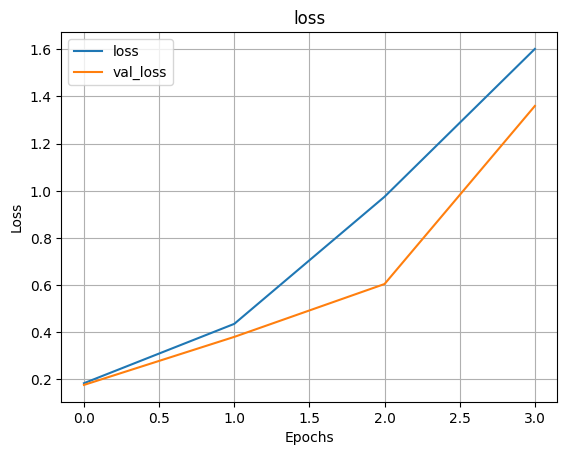

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 660us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95     25308
   Phishing Email       0.95      0.96      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



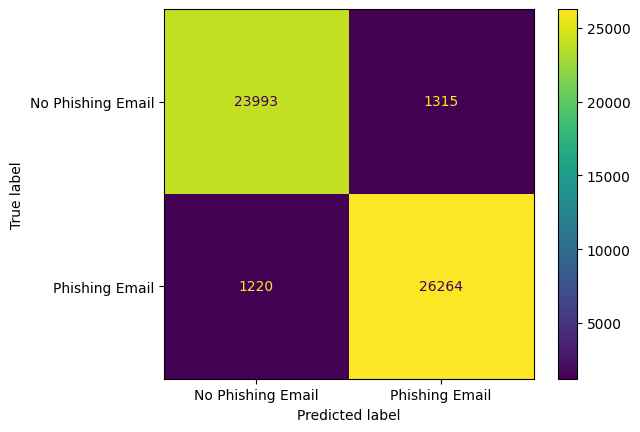

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95      6301
   Phishing Email       0.95      0.96      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



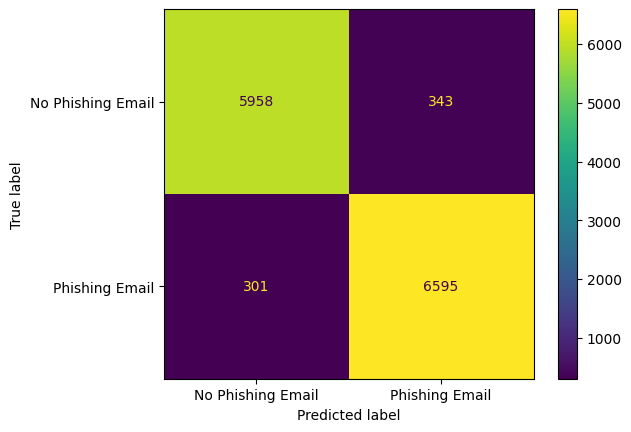


Config: layers=[128, 64], epochs=50, min_delta=0.001, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9422 - loss: 0.1831 - val_accuracy: 0.9502 - val_loss: 0.1745
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9332 - loss: 0.3453 - val_accuracy: 0.9448 - val_loss: 0.3463
Epoch 3/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9257 - loss: 0.8926 - val_accuracy: 0.9069 - val_loss: 1.6803
Epoch 4/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9277 - loss: 1.3208 - val_accuracy: 0.9255 - val_loss: 1.5993
Epoch 5/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9267 - loss: 2.0658 - val_accuracy: 0.9509 - val_loss: 1.3639
Epoch 6/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9279 - loss: 2.5479 - val_accuracy: 0.9488 - val_loss: 1.7699
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1745, stopped at epoch 6

Print History


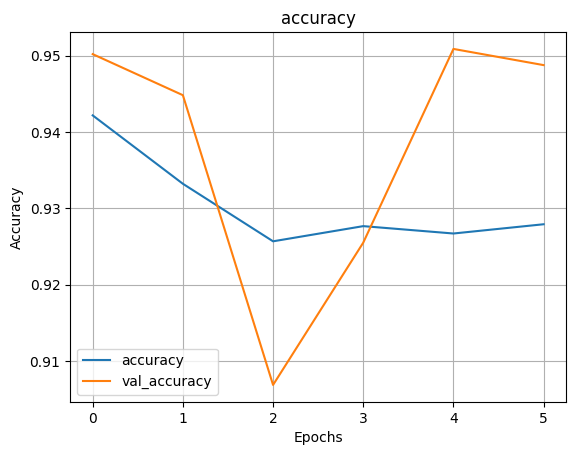

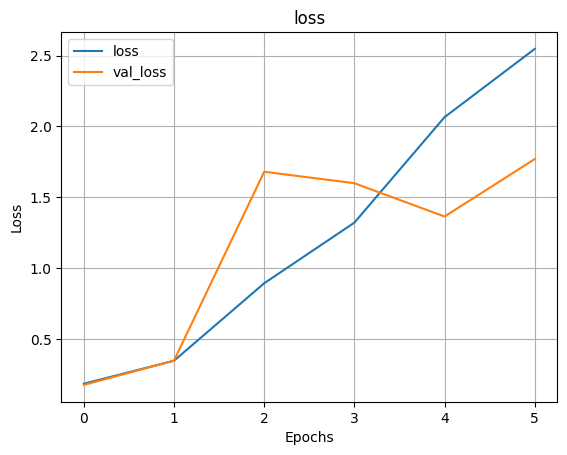

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 659us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.95      0.95     25308
   Phishing Email       0.96      0.95      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



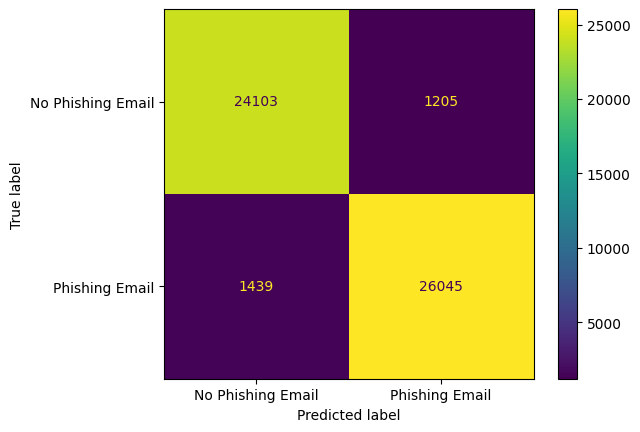

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95      6301
   Phishing Email       0.95      0.95      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



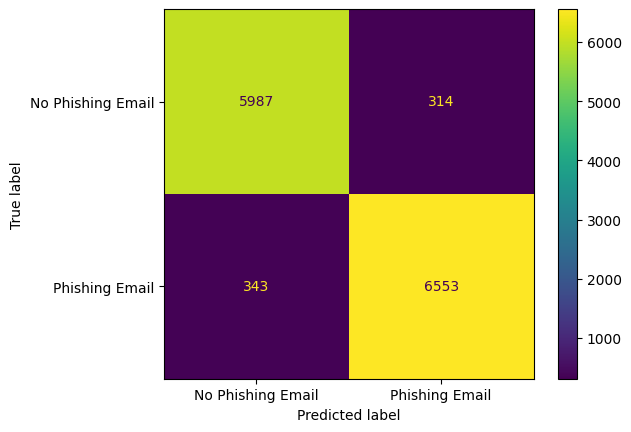


Config: layers=[128, 64], epochs=100, min_delta=0.0, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9411 - loss: 0.1821 - val_accuracy: 0.9045 - val_loss: 0.4073
Epoch 2/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9332 - loss: 0.3367 - val_accuracy: 0.9559 - val_loss: 0.2342
Epoch 3/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9245 - loss: 0.7529 - val_accuracy: 0.9013 - val_loss: 1.1616
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.2342, stopped at epoch 3

Print History


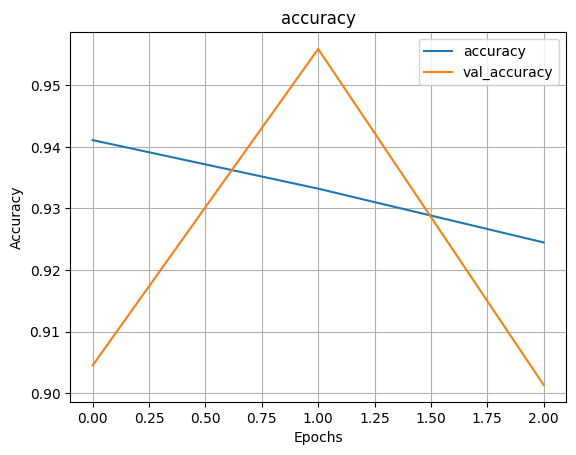

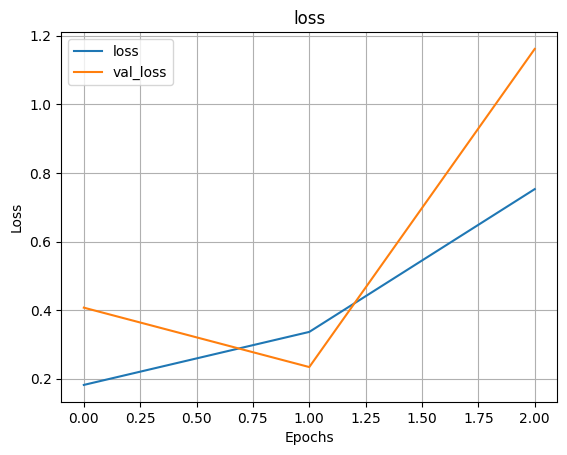

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 665us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.96      0.95     25308
   Phishing Email       0.96      0.95      0.96     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



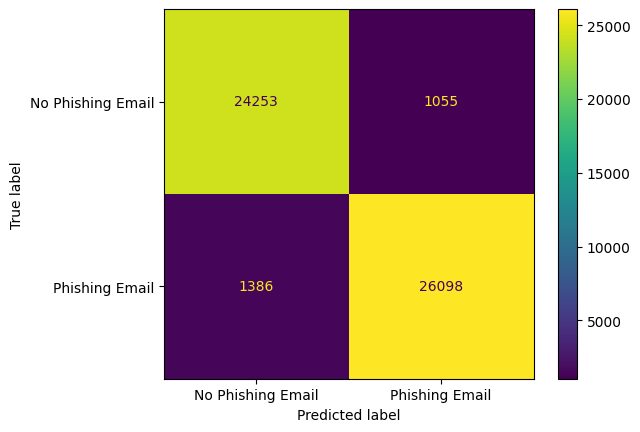

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



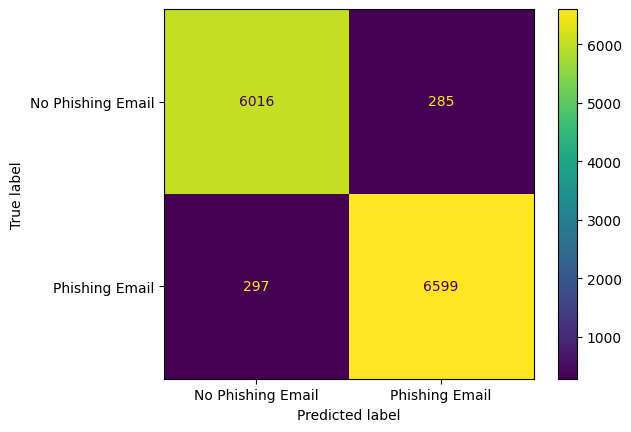


Config: layers=[128, 64], epochs=100, min_delta=0.0, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 6ms/step - accuracy: 0.9414 - loss: 0.1821 - val_accuracy: 0.9512 - val_loss: 0.1754
Epoch 2/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9274 - loss: 0.4475 - val_accuracy: 0.9481 - val_loss: 0.4374
Epoch 3/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9263 - loss: 0.9040 - val_accuracy: 0.9509 - val_loss: 0.6533
Epoch 4/100
1650/1650 - 9s - 5ms/step - accuracy: 0.9239 - loss: 1.4290 - val_accuracy: 0.9482 - val_loss: 0.9469
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1754, stopped at epoch 4

Print History


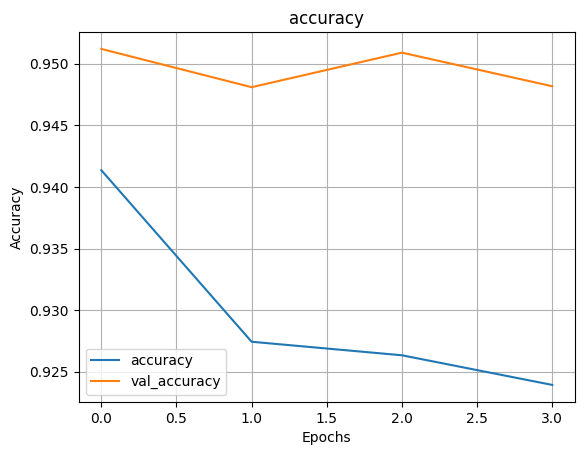

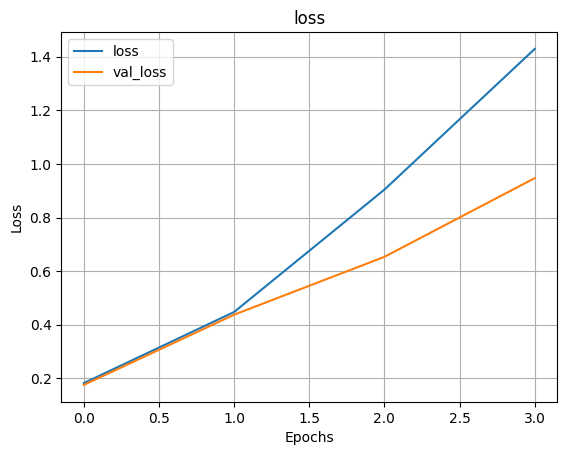

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.94      0.95     25308
   Phishing Email       0.95      0.96      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



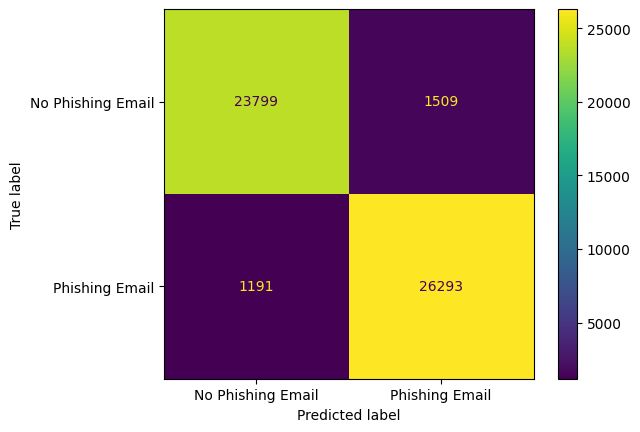

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.94      0.95      6301
   Phishing Email       0.95      0.96      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



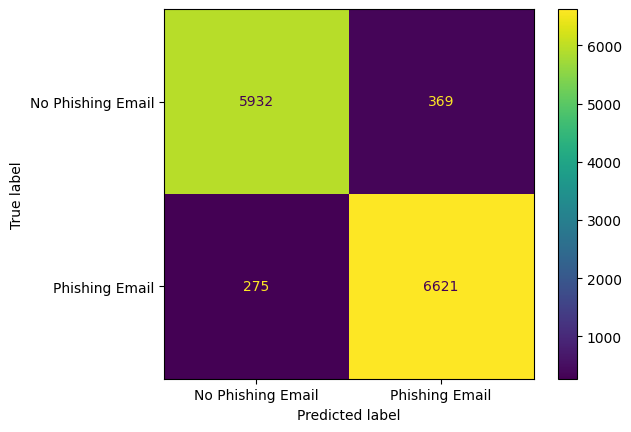


Config: layers=[128, 64], epochs=100, min_delta=0.0, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9416 - loss: 0.1834 - val_accuracy: 0.9442 - val_loss: 0.1961
Epoch 2/100
1650/1650 - 9s - 5ms/step - accuracy: 0.9317 - loss: 0.3971 - val_accuracy: 0.9517 - val_loss: 0.3487
Epoch 3/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9292 - loss: 0.7338 - val_accuracy: 0.9057 - val_loss: 1.0863
Epoch 4/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9291 - loss: 1.2307 - val_accuracy: 0.9511 - val_loss: 0.8178
Epoch 5/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9240 - loss: 1.9644 - val_accuracy: 0.9357 - val_loss: 1.8681
Epoch 6/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9259 - loss: 2.8186 - val_accuracy: 0.9172 - val_loss: 3.4949
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1961, stopped at epoch 6

Print History


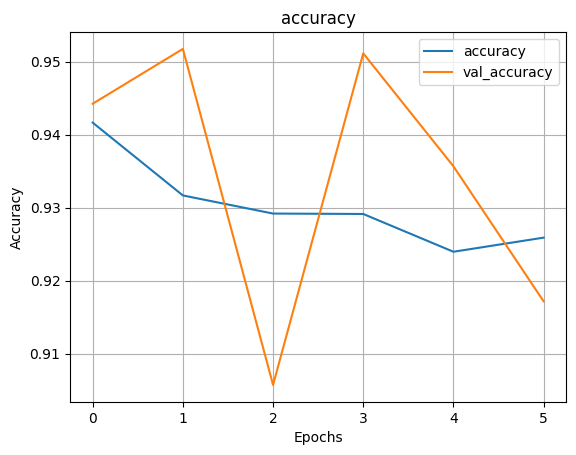

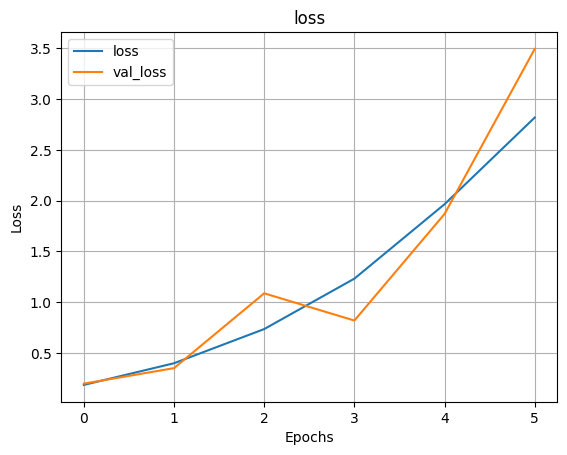

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 649us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.94      0.94     25308
   Phishing Email       0.94      0.94      0.94     27484

         accuracy                           0.94     52792
        macro avg       0.94      0.94      0.94     52792
     weighted avg       0.94      0.94      0.94     52792



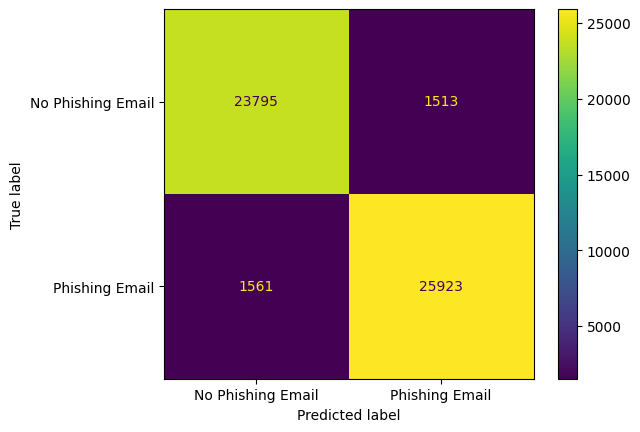

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.94      0.94      6301
   Phishing Email       0.95      0.95      0.95      6896

         accuracy                           0.94     13197
        macro avg       0.94      0.94      0.94     13197
     weighted avg       0.94      0.94      0.94     13197



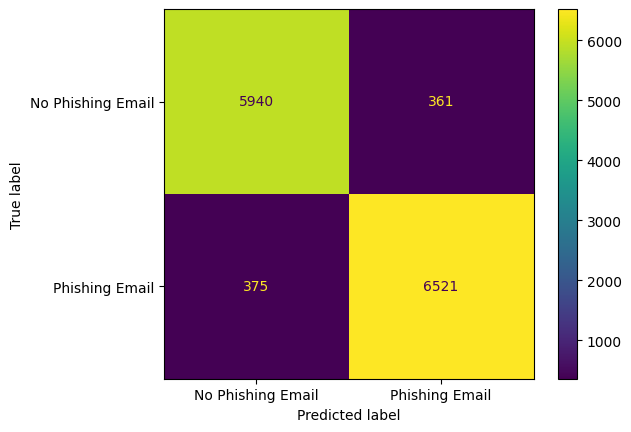


Config: layers=[128, 64], epochs=100, min_delta=0.001, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9411 - loss: 0.1860 - val_accuracy: 0.9168 - val_loss: 0.4093
Epoch 2/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9278 - loss: 0.4796 - val_accuracy: 0.9285 - val_loss: 0.7123
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.4093, stopped at epoch 2

Print History


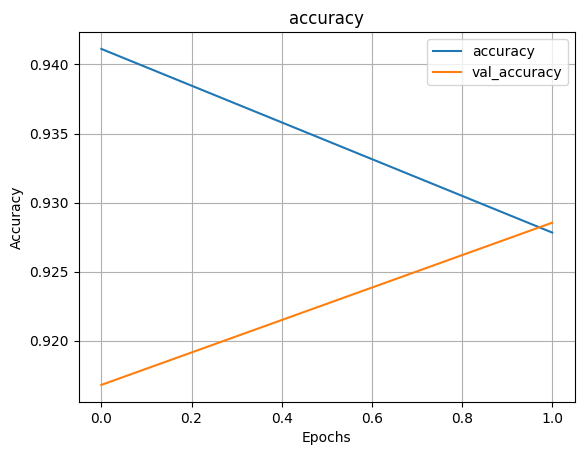

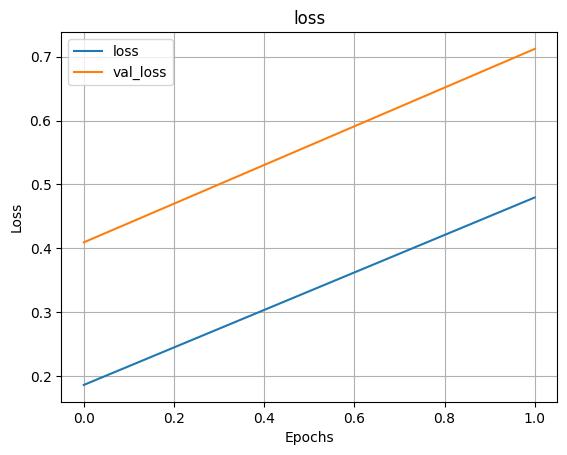

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 654us/step
                   precision    recall  f1-score   support

No Phishing Email       0.91      0.91      0.91     25308
   Phishing Email       0.91      0.92      0.92     27484

         accuracy                           0.91     52792
        macro avg       0.91      0.91      0.91     52792
     weighted avg       0.91      0.91      0.91     52792



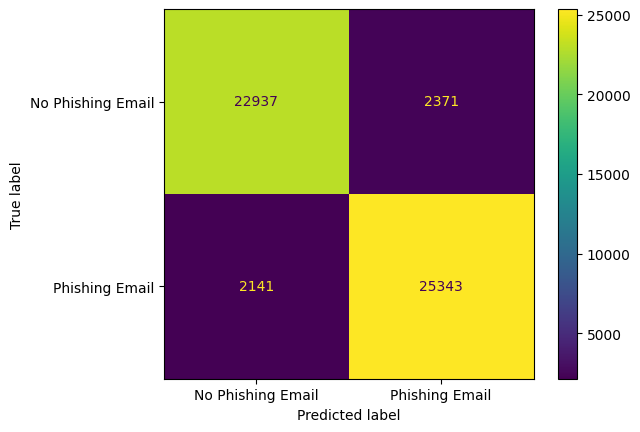

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step
                   precision    recall  f1-score   support

No Phishing Email       0.92      0.91      0.91      6301
   Phishing Email       0.92      0.92      0.92      6896

         accuracy                           0.92     13197
        macro avg       0.92      0.92      0.92     13197
     weighted avg       0.92      0.92      0.92     13197



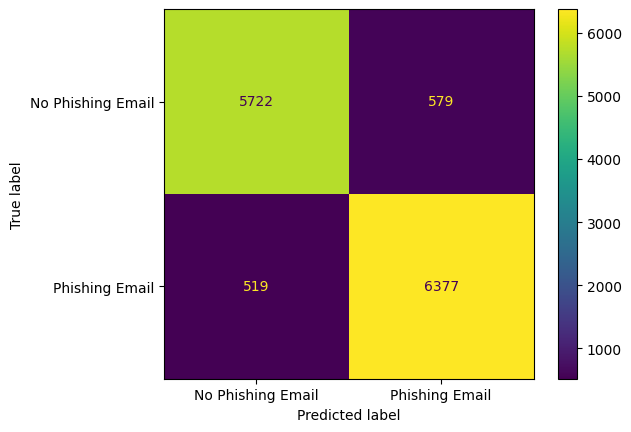


Config: layers=[128, 64], epochs=100, min_delta=0.001, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9421 - loss: 0.1842 - val_accuracy: 0.9414 - val_loss: 0.2107
Epoch 2/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9296 - loss: 0.4215 - val_accuracy: 0.9037 - val_loss: 1.1747
Epoch 3/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9239 - loss: 0.8801 - val_accuracy: 0.9364 - val_loss: 0.7977
Epoch 4/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9228 - loss: 1.5716 - val_accuracy: 0.9446 - val_loss: 1.4793
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.2107, stopped at epoch 4

Print History


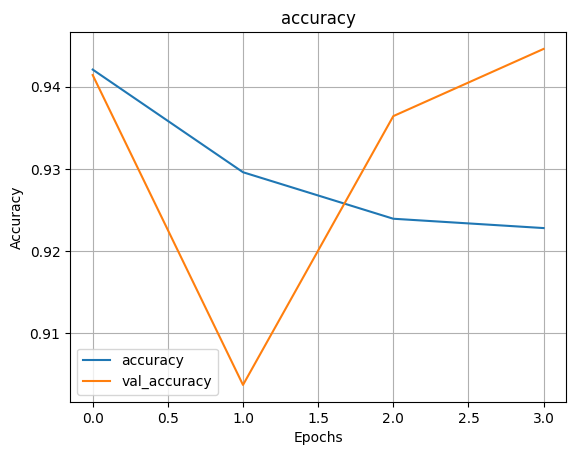

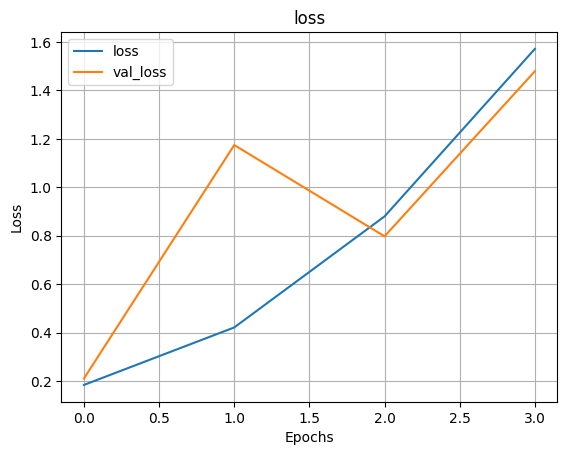

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 654us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.94      0.94     25308
   Phishing Email       0.94      0.94      0.94     27484

         accuracy                           0.94     52792
        macro avg       0.94      0.94      0.94     52792
     weighted avg       0.94      0.94      0.94     52792



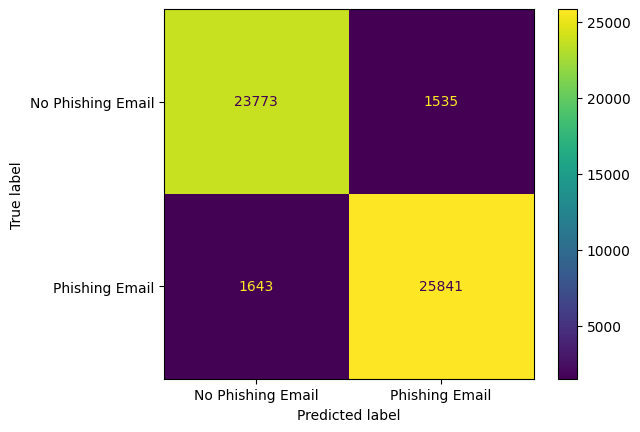

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.94      0.94      6301
   Phishing Email       0.94      0.94      0.94      6896

         accuracy                           0.94     13197
        macro avg       0.94      0.94      0.94     13197
     weighted avg       0.94      0.94      0.94     13197



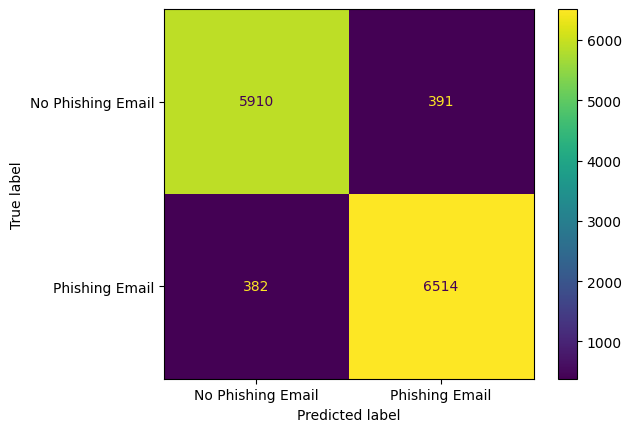


Config: layers=[128, 64], epochs=100, min_delta=0.001, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9412 - loss: 0.1775 - val_accuracy: 0.9271 - val_loss: 0.2873
Epoch 2/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9318 - loss: 0.3488 - val_accuracy: 0.9457 - val_loss: 0.3208
Epoch 3/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9236 - loss: 0.8543 - val_accuracy: 0.8500 - val_loss: 3.9023
Epoch 4/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9274 - loss: 1.2540 - val_accuracy: 0.9336 - val_loss: 1.3808
Epoch 5/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9235 - loss: 1.8599 - val_accuracy: 0.8280 - val_loss: 6.5393
Epoch 6/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9212 - loss: 3.2308 - val_accuracy: 0.9489 - val_loss: 2.1362
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.2873, stopped at epoch 6

Print History


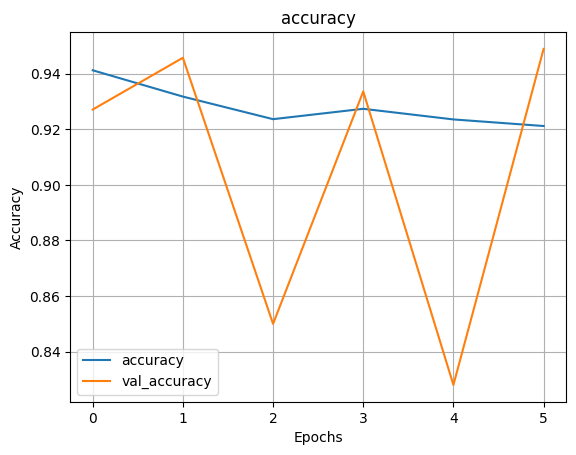

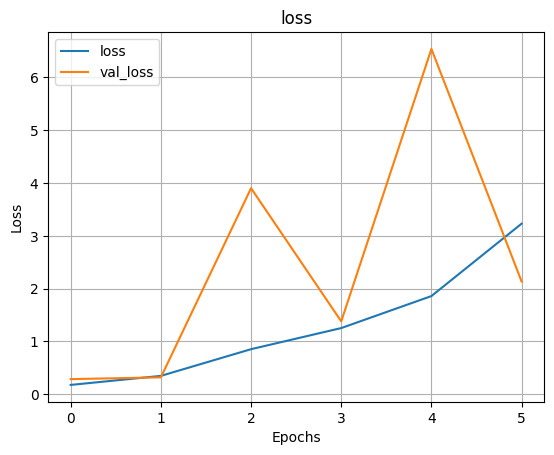

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step
                   precision    recall  f1-score   support

No Phishing Email       0.91      0.94      0.92     25308
   Phishing Email       0.94      0.92      0.93     27484

         accuracy                           0.93     52792
        macro avg       0.93      0.93      0.93     52792
     weighted avg       0.93      0.93      0.93     52792



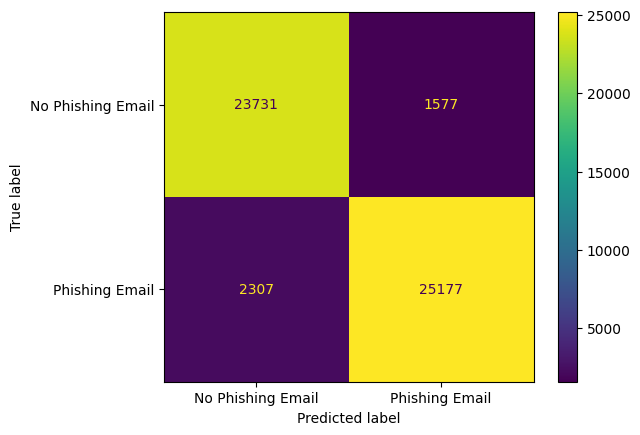

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step
                   precision    recall  f1-score   support

No Phishing Email       0.91      0.94      0.92      6301
   Phishing Email       0.94      0.92      0.93      6896

         accuracy                           0.93     13197
        macro avg       0.93      0.93      0.93     13197
     weighted avg       0.93      0.93      0.93     13197



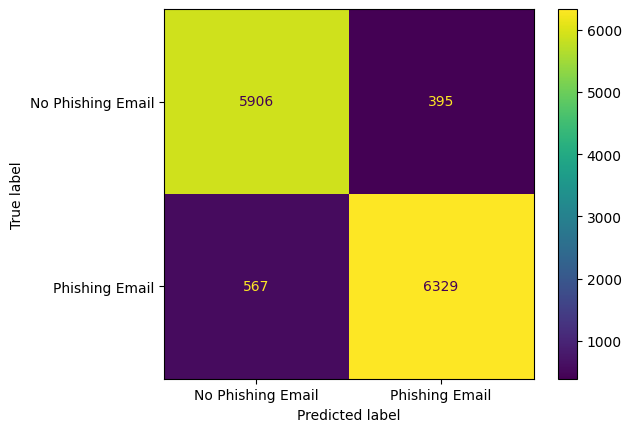


Config: layers=[256, 128, 64], epochs=50, min_delta=0.0, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.9018 - loss: 18.2378 - val_accuracy: 0.7795 - val_loss: 366.0065
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9059 - loss: 183.3844 - val_accuracy: 0.8921 - val_loss: 543.3166
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=366.0065, stopped at epoch 2

Print History


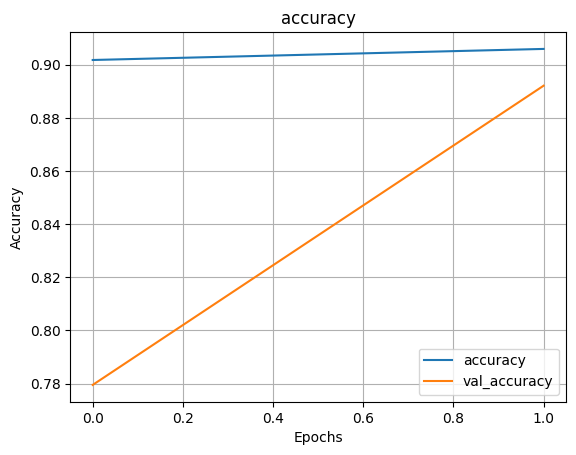

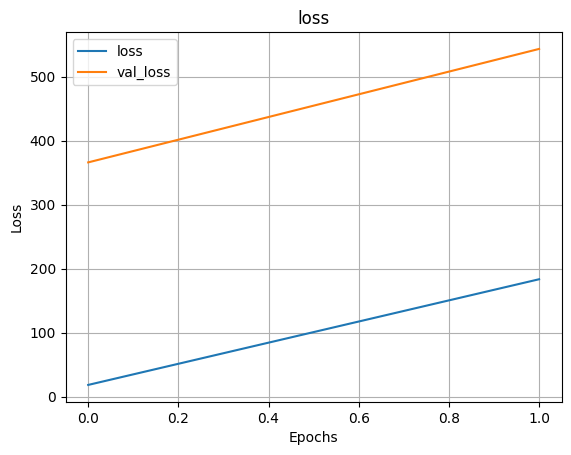

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step
                   precision    recall  f1-score   support

No Phishing Email       0.74      0.85      0.79     25308
   Phishing Email       0.84      0.73      0.78     27484

         accuracy                           0.79     52792
        macro avg       0.79      0.79      0.79     52792
     weighted avg       0.79      0.79      0.79     52792



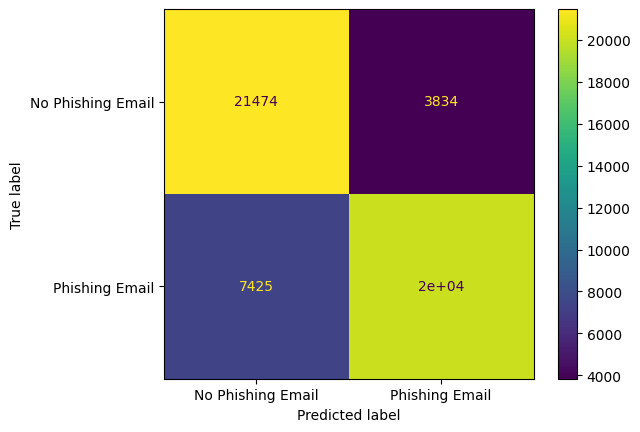

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step
                   precision    recall  f1-score   support

No Phishing Email       0.73      0.84      0.78      6301
   Phishing Email       0.83      0.72      0.77      6896

         accuracy                           0.78     13197
        macro avg       0.78      0.78      0.78     13197
     weighted avg       0.79      0.78      0.78     13197



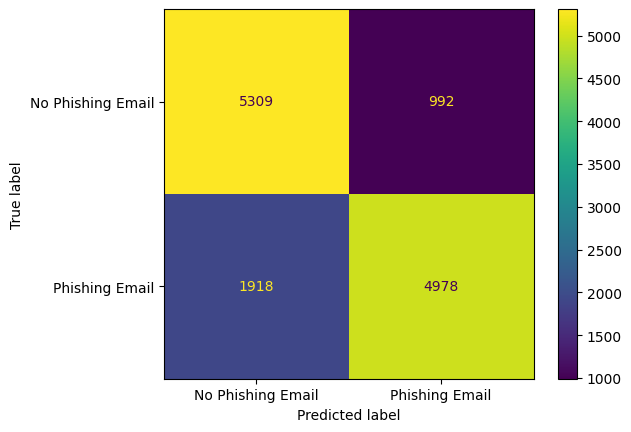


Config: layers=[256, 128, 64], epochs=50, min_delta=0.0, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.9088 - loss: 11.0430 - val_accuracy: 0.9363 - val_loss: 29.6011
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9156 - loss: 147.9316 - val_accuracy: 0.9520 - val_loss: 81.7261
Epoch 3/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9090 - loss: 640.1635 - val_accuracy: 0.9557 - val_loss: 360.7862
Epoch 4/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9259 - loss: 897.3405 - val_accuracy: 0.9217 - val_loss: 941.8177
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=29.6011, stopped at epoch 4

Print History


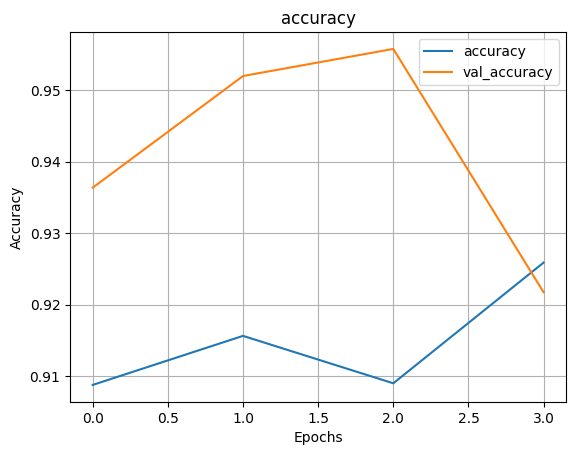

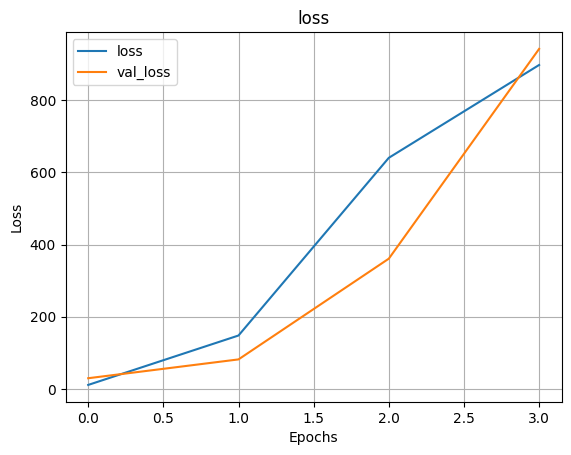

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step
                   precision    recall  f1-score   support

No Phishing Email       0.92      0.94      0.93     25308
   Phishing Email       0.94      0.93      0.94     27484

         accuracy                           0.93     52792
        macro avg       0.93      0.93      0.93     52792
     weighted avg       0.93      0.93      0.93     52792



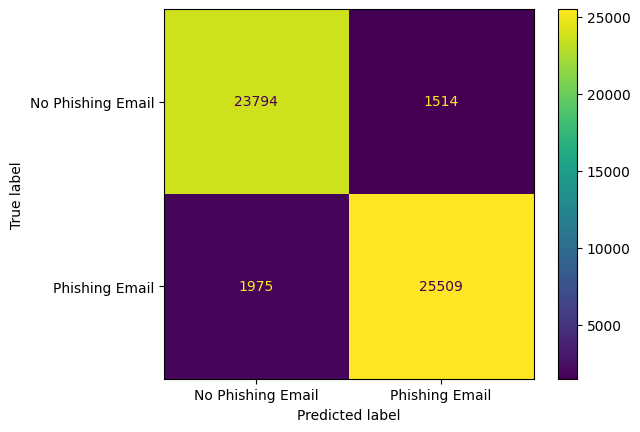

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step
                   precision    recall  f1-score   support

No Phishing Email       0.93      0.94      0.93      6301
   Phishing Email       0.94      0.93      0.94      6896

         accuracy                           0.94     13197
        macro avg       0.94      0.94      0.94     13197
     weighted avg       0.94      0.94      0.94     13197



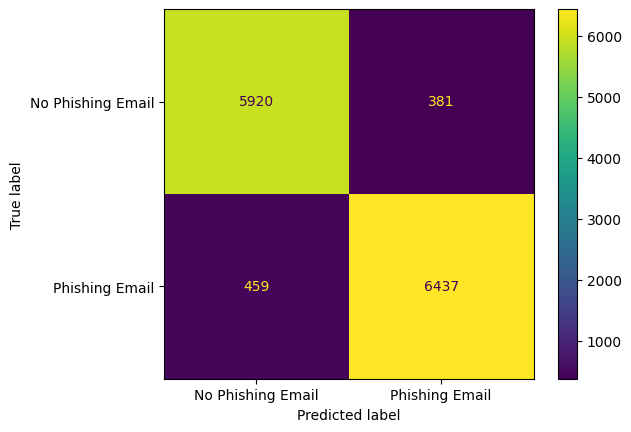


Config: layers=[256, 128, 64], epochs=50, min_delta=0.0, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8921 - loss: 60.1283 - val_accuracy: 0.8270 - val_loss: 332.1451
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.8992 - loss: 676.4664 - val_accuracy: 0.7239 - val_loss: 5920.6797
Epoch 3/50
1650/1650 - 11s - 6ms/step - accuracy: 0.9028 - loss: 2193.5793 - val_accuracy: 0.7416 - val_loss: 17614.7129
Epoch 4/50
1650/1650 - 10s - 6ms/step - accuracy: 0.9072 - loss: 4267.6914 - val_accuracy: 0.9552 - val_loss: 1618.8846
Epoch 5/50
1650/1650 - 10s - 6ms/step - accuracy: 0.9060 - loss: 8130.7749 - val_accuracy: 0.9554 - val_loss: 3076.4993
Epoch 6/50
1650/1650 - 11s - 6ms/step - accuracy: 0.9097 - loss: 10635.6455 - val_accuracy: 0.9570 - val_loss: 3401.8389
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=332.1451, stopped at epoch 6

Print History


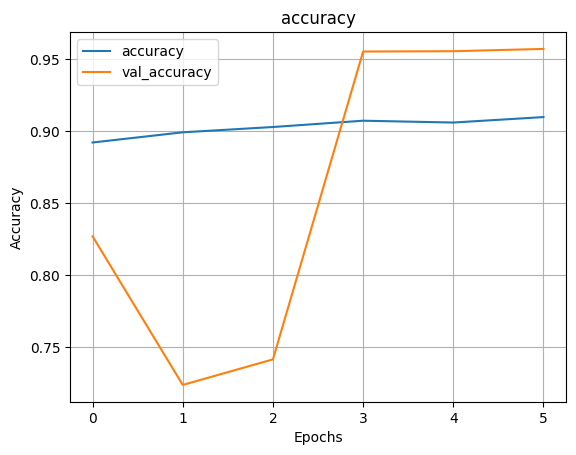

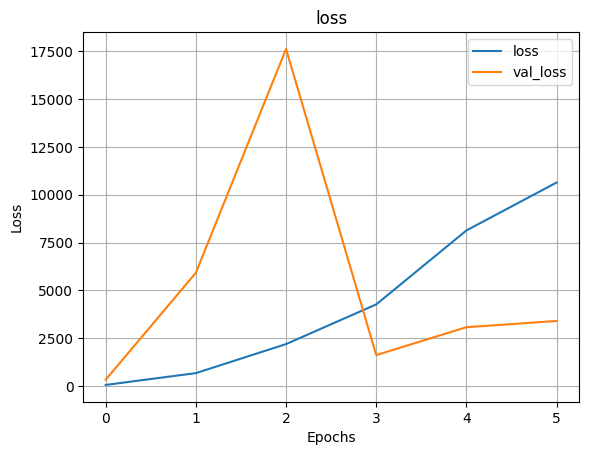

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step
                   precision    recall  f1-score   support

No Phishing Email       0.77      0.91      0.83     25308
   Phishing Email       0.90      0.76      0.82     27484

         accuracy                           0.83     52792
        macro avg       0.84      0.83      0.83     52792
     weighted avg       0.84      0.83      0.83     52792



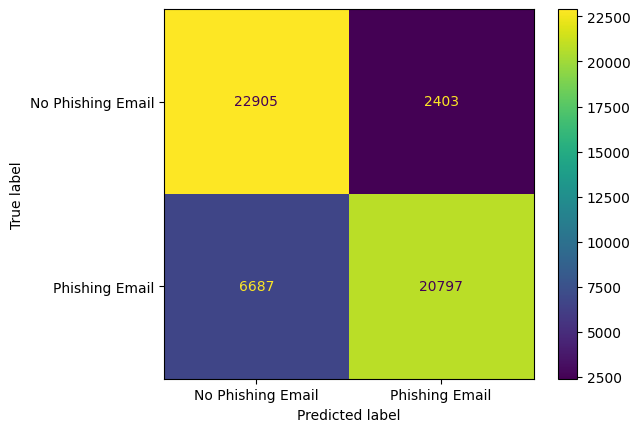

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step
                   precision    recall  f1-score   support

No Phishing Email       0.78      0.90      0.83      6301
   Phishing Email       0.89      0.76      0.82      6896

         accuracy                           0.83     13197
        macro avg       0.83      0.83      0.83     13197
     weighted avg       0.84      0.83      0.83     13197



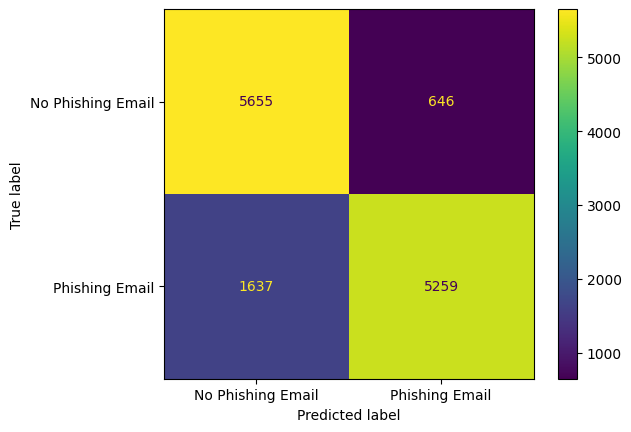


Config: layers=[256, 128, 64], epochs=50, min_delta=0.001, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 12s - 7ms/step - accuracy: 0.8977 - loss: 25.7278 - val_accuracy: 0.9193 - val_loss: 59.6780
Epoch 2/50
1650/1650 - 11s - 6ms/step - accuracy: 0.9031 - loss: 253.2947 - val_accuracy: 0.9498 - val_loss: 155.5661
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=59.6780, stopped at epoch 2

Print History


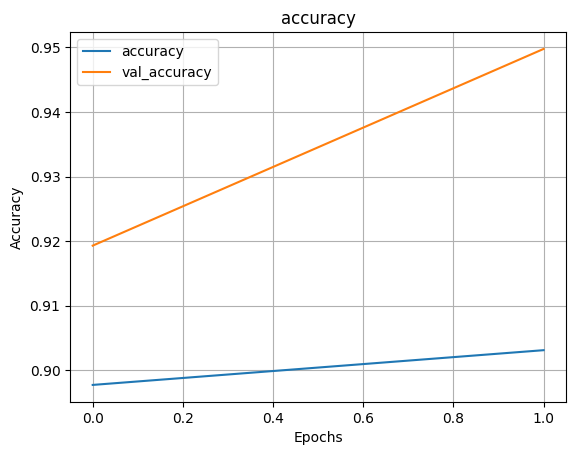

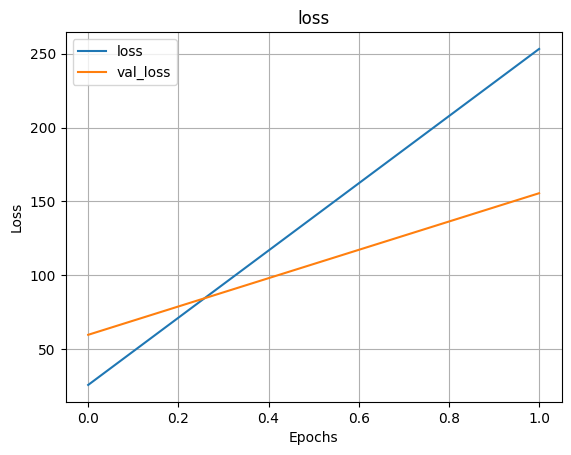

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step
                   precision    recall  f1-score   support

No Phishing Email       0.91      0.92      0.91     25308
   Phishing Email       0.92      0.91      0.92     27484

         accuracy                           0.92     52792
        macro avg       0.91      0.92      0.91     52792
     weighted avg       0.92      0.92      0.92     52792



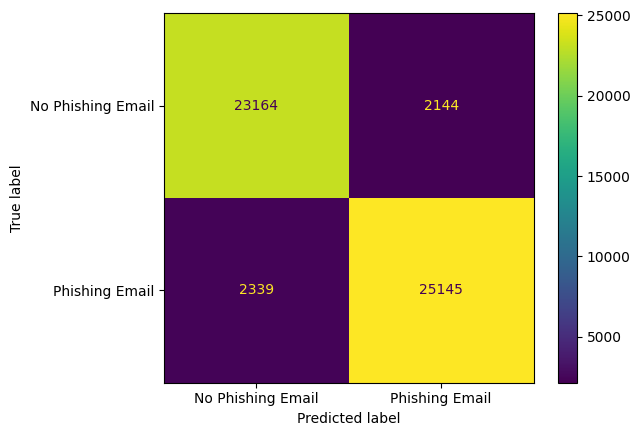

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step
                   precision    recall  f1-score   support

No Phishing Email       0.91      0.92      0.92      6301
   Phishing Email       0.93      0.92      0.92      6896

         accuracy                           0.92     13197
        macro avg       0.92      0.92      0.92     13197
     weighted avg       0.92      0.92      0.92     13197



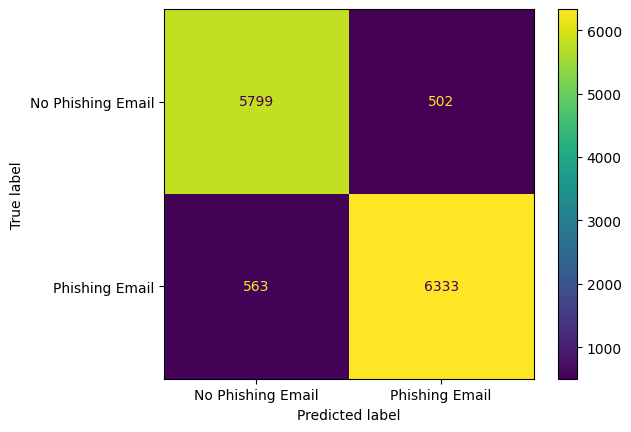


Config: layers=[256, 128, 64], epochs=50, min_delta=0.001, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8966 - loss: 43.6082 - val_accuracy: 0.8716 - val_loss: 157.3778
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9023 - loss: 535.0579 - val_accuracy: 0.9501 - val_loss: 358.3395
Epoch 3/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9125 - loss: 1238.6193 - val_accuracy: 0.9242 - val_loss: 1536.5542
Epoch 4/50
1650/1650 - 11s - 6ms/step - accuracy: 0.9156 - loss: 2177.4951 - val_accuracy: 0.9180 - val_loss: 2353.9702
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=157.3778, stopped at epoch 4

Print History


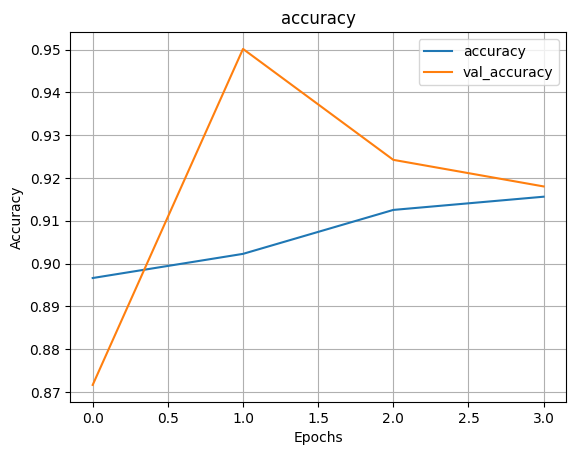

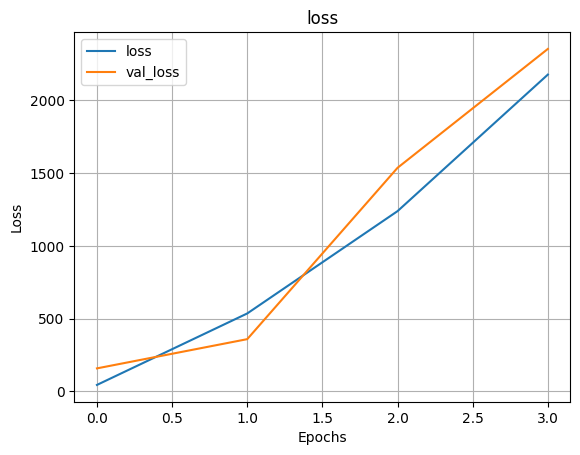

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 683us/step
                   precision    recall  f1-score   support

No Phishing Email       0.83      0.94      0.88     25308
   Phishing Email       0.94      0.82      0.87     27484

         accuracy                           0.88     52792
        macro avg       0.88      0.88      0.88     52792
     weighted avg       0.88      0.88      0.88     52792



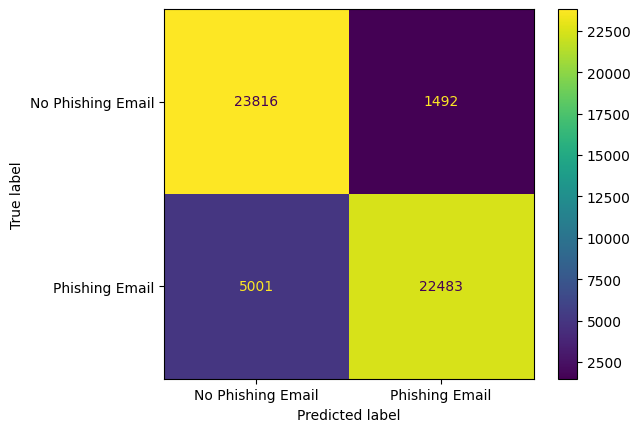

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step
                   precision    recall  f1-score   support

No Phishing Email       0.82      0.93      0.87      6301
   Phishing Email       0.93      0.82      0.87      6896

         accuracy                           0.87     13197
        macro avg       0.88      0.87      0.87     13197
     weighted avg       0.88      0.87      0.87     13197



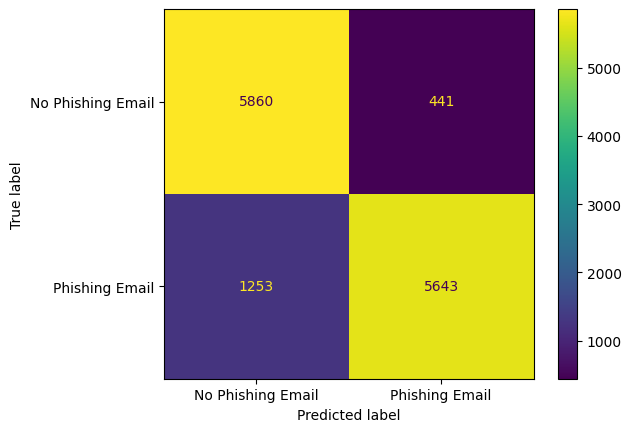


Config: layers=[256, 128, 64], epochs=50, min_delta=0.001, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8891 - loss: 65.1828 - val_accuracy: 0.8925 - val_loss: 196.7592
Epoch 2/50
1650/1650 - 11s - 6ms/step - accuracy: 0.8931 - loss: 733.0361 - val_accuracy: 0.9072 - val_loss: 1126.8582
Epoch 3/50
1650/1650 - 11s - 6ms/step - accuracy: 0.9062 - loss: 1687.6771 - val_accuracy: 0.9077 - val_loss: 1503.6729
Epoch 4/50
1650/1650 - 10s - 6ms/step - accuracy: 0.9058 - loss: 3381.4138 - val_accuracy: 0.9494 - val_loss: 1597.0045
Epoch 5/50
1650/1650 - 10s - 6ms/step - accuracy: 0.9099 - loss: 5441.7349 - val_accuracy: 0.9559 - val_loss: 1775.4961
Epoch 6/50
1650/1650 - 11s - 6ms/step - accuracy: 0.9046 - loss: 9247.6699 - val_accuracy: 0.8596 - val_loss: 13901.5967
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=196.7592, stopped at epoch 6

Print History


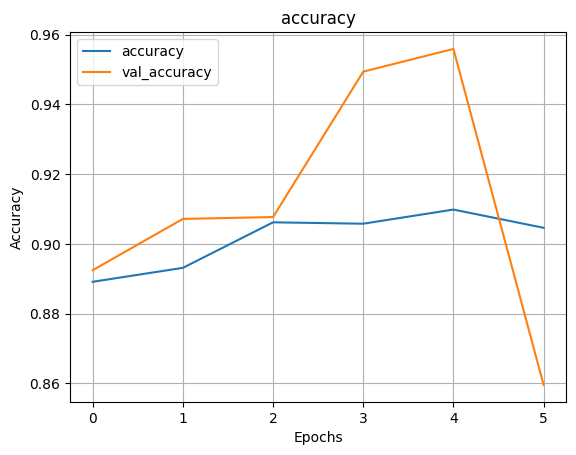

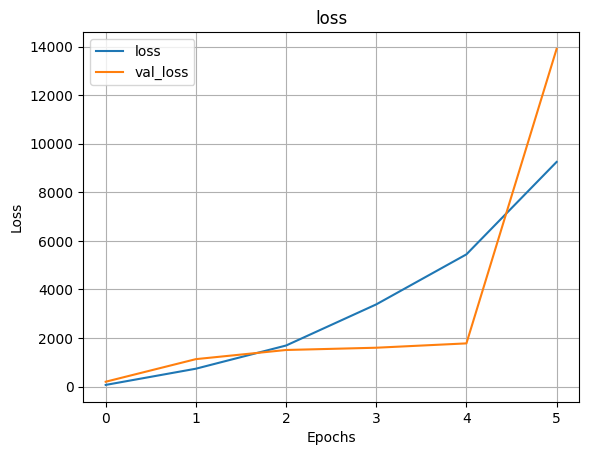

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 649us/step
                   precision    recall  f1-score   support

No Phishing Email       0.87      0.91      0.89     25308
   Phishing Email       0.91      0.87      0.89     27484

         accuracy                           0.89     52792
        macro avg       0.89      0.89      0.89     52792
     weighted avg       0.89      0.89      0.89     52792



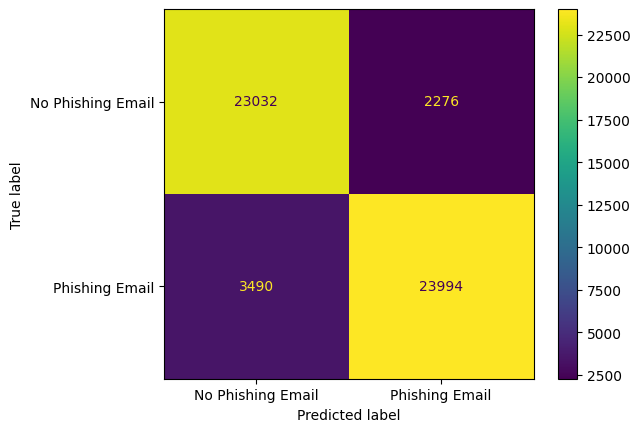

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step
                   precision    recall  f1-score   support

No Phishing Email       0.87      0.91      0.89      6301
   Phishing Email       0.91      0.88      0.89      6896

         accuracy                           0.89     13197
        macro avg       0.89      0.89      0.89     13197
     weighted avg       0.89      0.89      0.89     13197



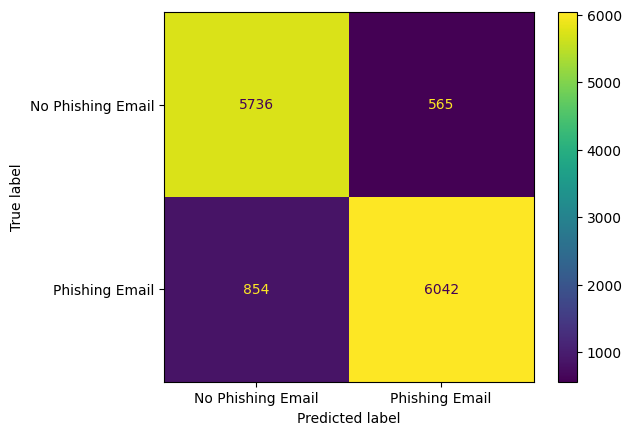


Config: layers=[256, 128, 64], epochs=100, min_delta=0.0, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8988 - loss: 42.0722 - val_accuracy: 0.9484 - val_loss: 44.6719
Epoch 2/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9111 - loss: 294.8604 - val_accuracy: 0.8694 - val_loss: 782.3797
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=44.6719, stopped at epoch 2

Print History


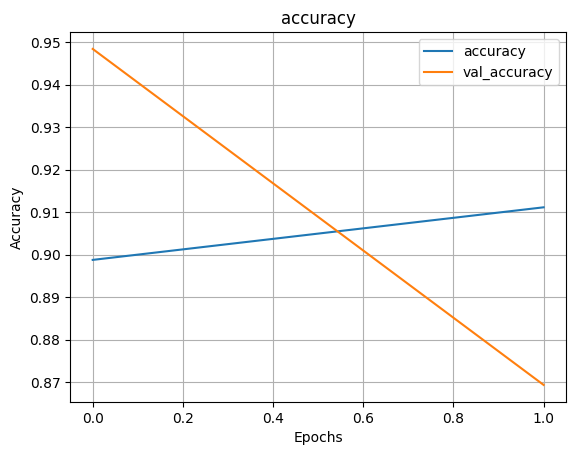

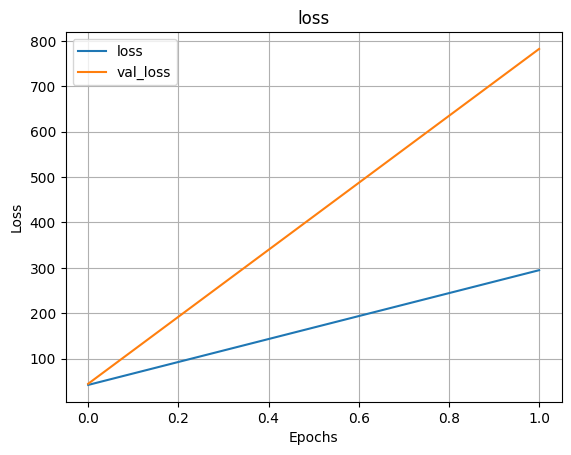

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 677us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.95      0.95     25308
   Phishing Email       0.96      0.94      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



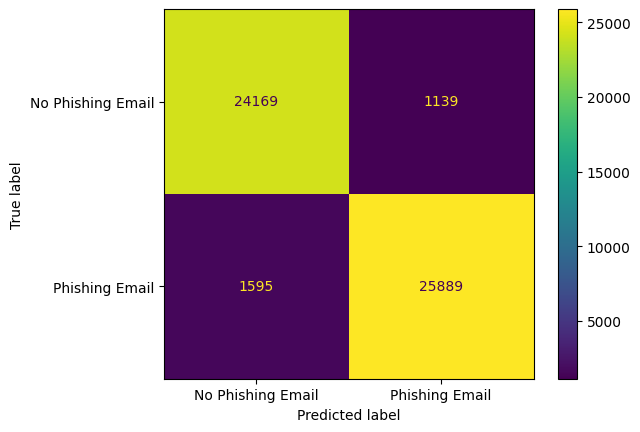

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.95      0.95      6301
   Phishing Email       0.95      0.95      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



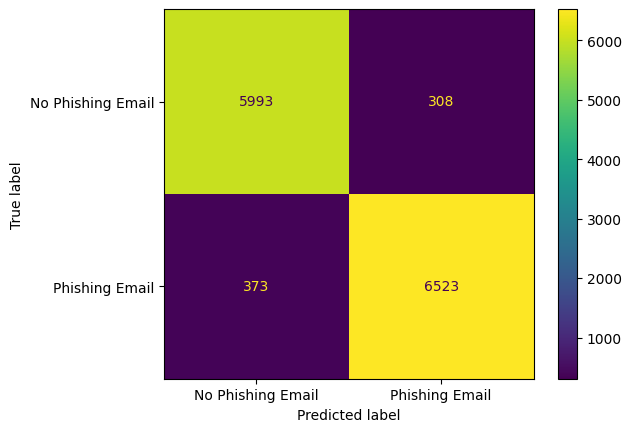


Config: layers=[256, 128, 64], epochs=100, min_delta=0.0, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8946 - loss: 35.9191 - val_accuracy: 0.8324 - val_loss: 248.8826
Epoch 2/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9059 - loss: 383.3371 - val_accuracy: 0.9048 - val_loss: 552.9949
Epoch 3/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9082 - loss: 1296.5657 - val_accuracy: 0.9573 - val_loss: 561.5172
Epoch 4/100
1650/1650 - 10s - 6ms/step - accuracy: 0.9143 - loss: 2249.2124 - val_accuracy: 0.9586 - val_loss: 895.4951
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=248.8826, stopped at epoch 4

Print History


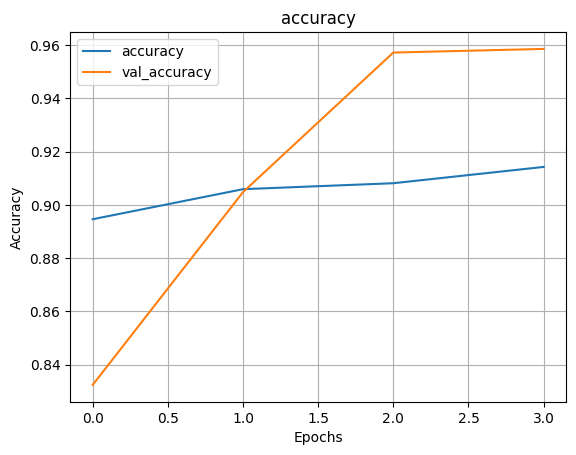

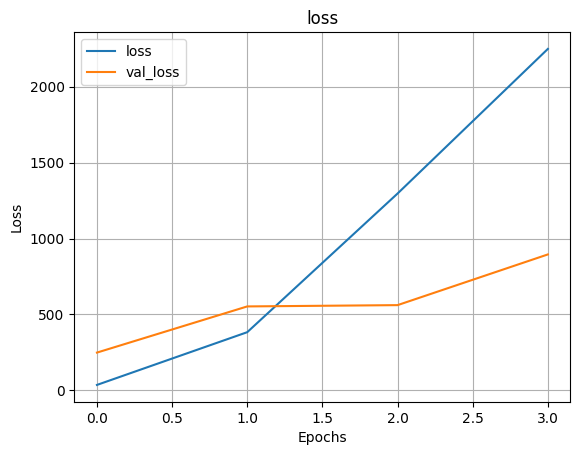

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step
                   precision    recall  f1-score   support

No Phishing Email       0.78      0.92      0.84     25308
   Phishing Email       0.91      0.76      0.83     27484

         accuracy                           0.84     52792
        macro avg       0.85      0.84      0.84     52792
     weighted avg       0.85      0.84      0.84     52792



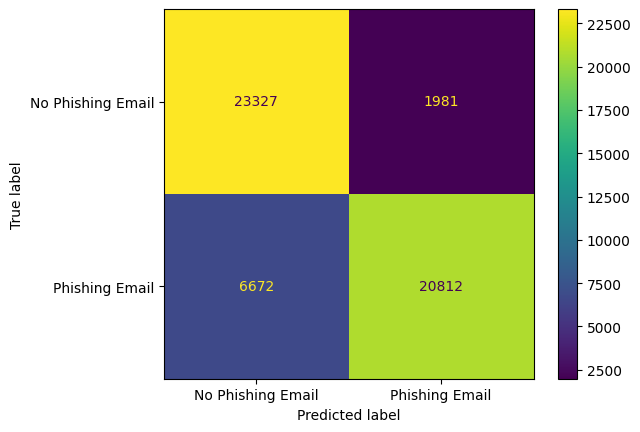

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step
                   precision    recall  f1-score   support

No Phishing Email       0.77      0.92      0.84      6301
   Phishing Email       0.91      0.75      0.82      6896

         accuracy                           0.83     13197
        macro avg       0.84      0.84      0.83     13197
     weighted avg       0.84      0.83      0.83     13197



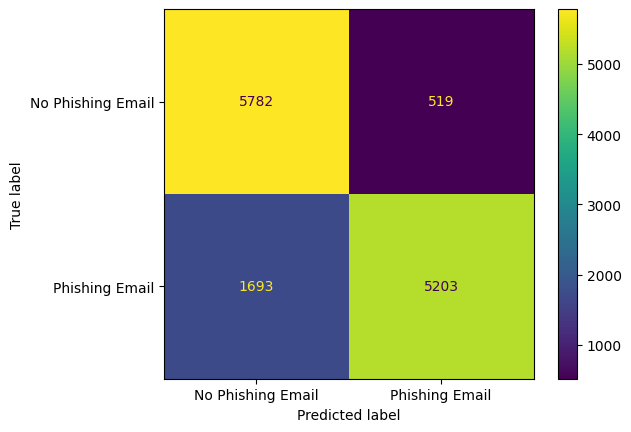


Config: layers=[256, 128, 64], epochs=100, min_delta=0.0, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8950 - loss: 41.5706 - val_accuracy: 0.9376 - val_loss: 48.2677
Epoch 2/100
1650/1650 - 11s - 6ms/step - accuracy: 0.8948 - loss: 620.3064 - val_accuracy: 0.9496 - val_loss: 392.5774
Epoch 3/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9079 - loss: 1440.6110 - val_accuracy: 0.8719 - val_loss: 4508.8726
Epoch 4/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9096 - loss: 2724.0693 - val_accuracy: 0.9481 - val_loss: 1377.2321
Epoch 5/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9143 - loss: 3733.3713 - val_accuracy: 0.9561 - val_loss: 1375.9666
Epoch 6/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9056 - loss: 7547.3799 - val_accuracy: 0.9367 - val_loss: 5833.4312
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=48.2677, stopped at epoch 6

Print History


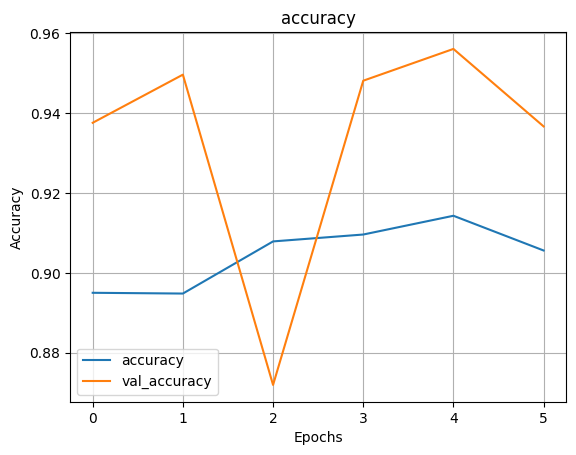

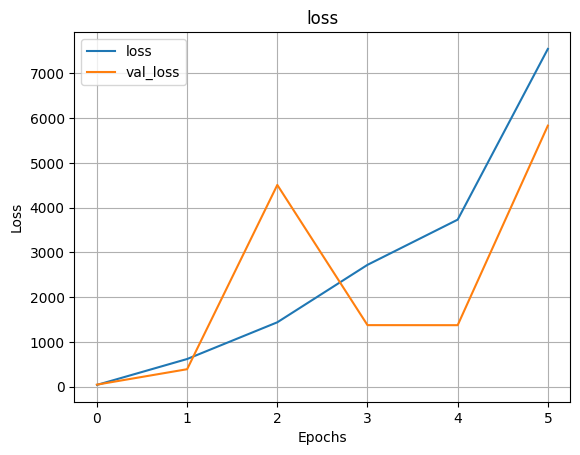

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step
                   precision    recall  f1-score   support

No Phishing Email       0.93      0.94      0.93     25308
   Phishing Email       0.94      0.93      0.94     27484

         accuracy                           0.93     52792
        macro avg       0.93      0.93      0.93     52792
     weighted avg       0.93      0.93      0.93     52792



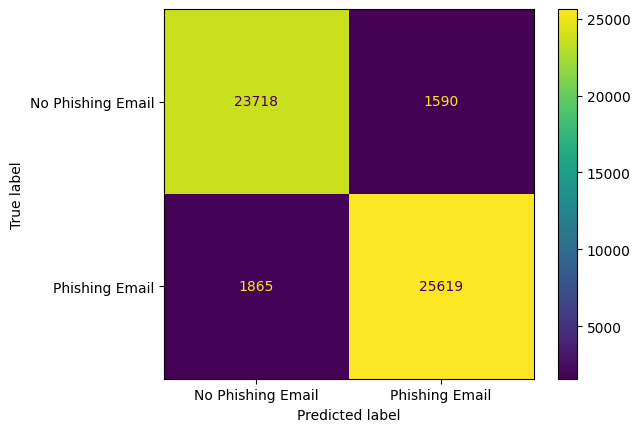

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step
                   precision    recall  f1-score   support

No Phishing Email       0.93      0.94      0.93      6301
   Phishing Email       0.94      0.94      0.94      6896

         accuracy                           0.94     13197
        macro avg       0.94      0.94      0.94     13197
     weighted avg       0.94      0.94      0.94     13197



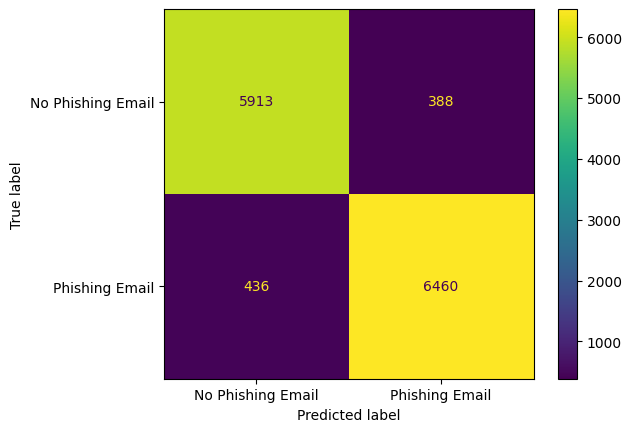


Config: layers=[256, 128, 64], epochs=100, min_delta=0.001, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8968 - loss: 21.9983 - val_accuracy: 0.9396 - val_loss: 43.4097
Epoch 2/100
1650/1650 - 11s - 7ms/step - accuracy: 0.8986 - loss: 288.1503 - val_accuracy: 0.9476 - val_loss: 210.5954
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=43.4097, stopped at epoch 2

Print History


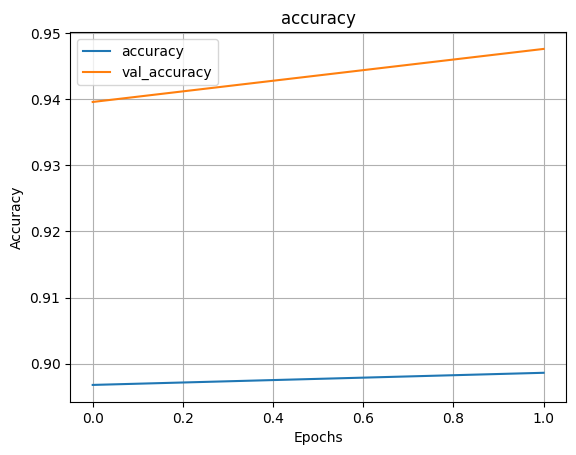

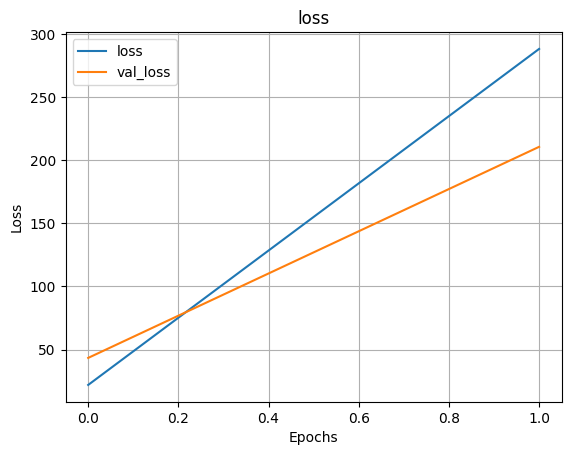

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.93      0.94     25308
   Phishing Email       0.94      0.95      0.94     27484

         accuracy                           0.94     52792
        macro avg       0.94      0.94      0.94     52792
     weighted avg       0.94      0.94      0.94     52792



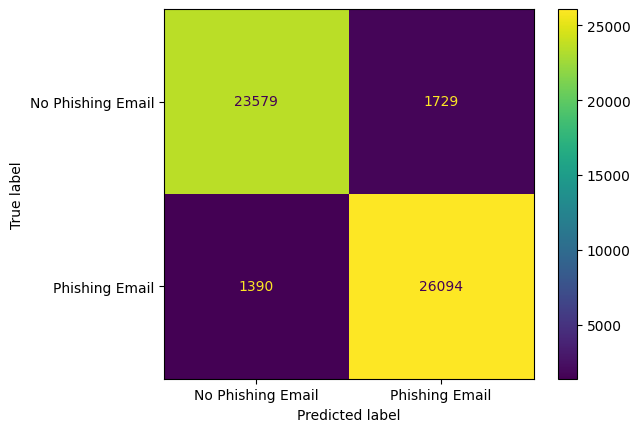

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.93      0.94      6301
   Phishing Email       0.93      0.95      0.94      6896

         accuracy                           0.94     13197
        macro avg       0.94      0.94      0.94     13197
     weighted avg       0.94      0.94      0.94     13197



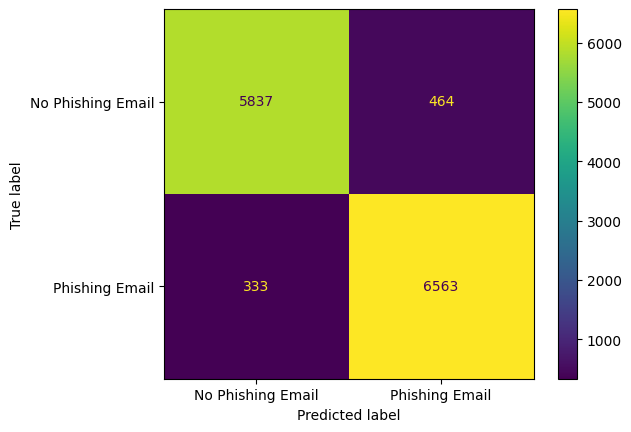


Config: layers=[256, 128, 64], epochs=100, min_delta=0.001, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8889 - loss: 67.8208 - val_accuracy: 0.9486 - val_loss: 74.6439
Epoch 2/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9067 - loss: 394.3432 - val_accuracy: 0.9218 - val_loss: 394.7505
Epoch 3/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9059 - loss: 1279.7106 - val_accuracy: 0.9523 - val_loss: 676.2800
Epoch 4/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9148 - loss: 2263.6230 - val_accuracy: 0.9548 - val_loss: 978.4384
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=74.6439, stopped at epoch 4

Print History


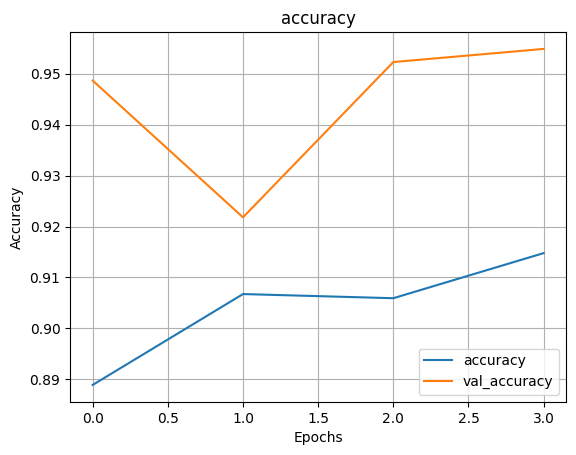

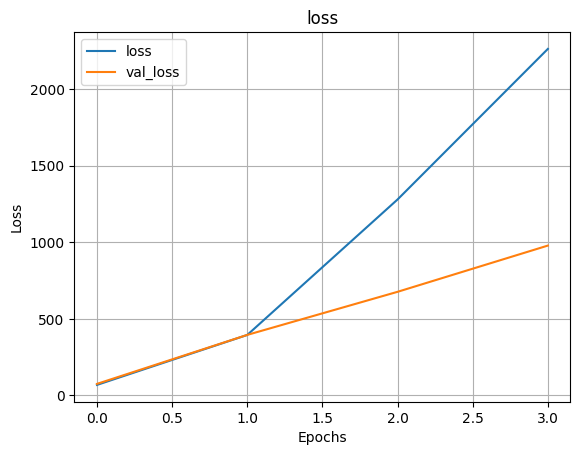

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.94      0.95     25308
   Phishing Email       0.94      0.96      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



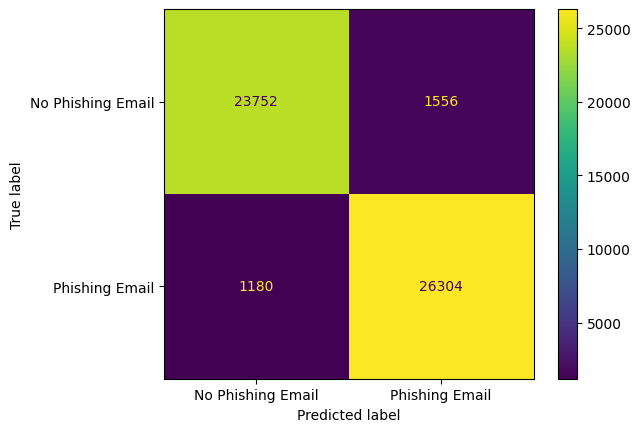

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.94      0.95      6301
   Phishing Email       0.94      0.96      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



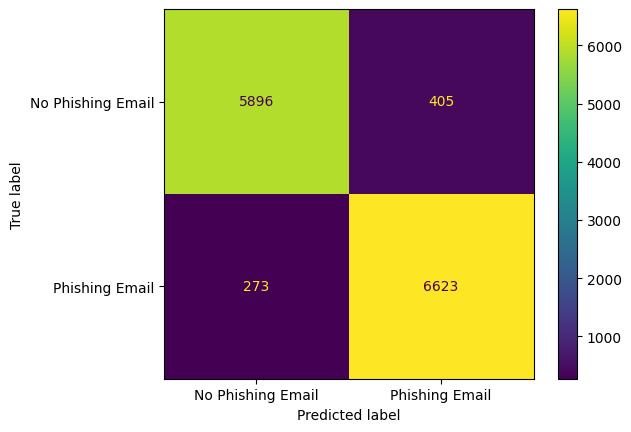


Config: layers=[256, 128, 64], epochs=100, min_delta=0.001, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8952 - loss: 37.9413 - val_accuracy: 0.8840 - val_loss: 163.9716
Epoch 2/100
1650/1650 - 11s - 6ms/step - accuracy: 0.8987 - loss: 447.1000 - val_accuracy: 0.8725 - val_loss: 1031.1902
Epoch 3/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9005 - loss: 1614.6014 - val_accuracy: 0.9481 - val_loss: 826.0729
Epoch 4/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9067 - loss: 3054.0530 - val_accuracy: 0.9534 - val_loss: 1265.9891
Epoch 5/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9078 - loss: 5296.3032 - val_accuracy: 0.8487 - val_loss: 13198.9648
Epoch 6/100
1650/1650 - 11s - 6ms/step - accuracy: 0.9048 - loss: 8448.5957 - val_accuracy: 0.9452 - val_loss: 4772.8530
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=163.9716, stopped at epoch 6

Print History


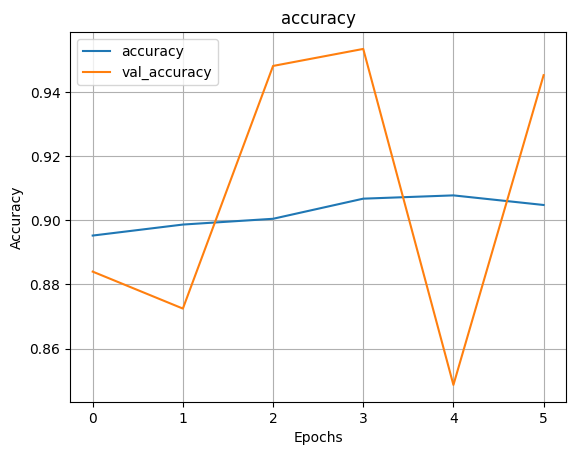

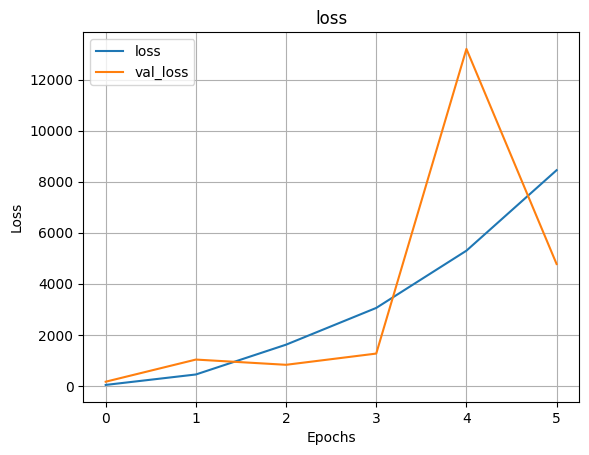

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 674us/step
                   precision    recall  f1-score   support

No Phishing Email       0.87      0.90      0.88     25308
   Phishing Email       0.91      0.87      0.89     27484

         accuracy                           0.89     52792
        macro avg       0.89      0.89      0.89     52792
     weighted avg       0.89      0.89      0.89     52792



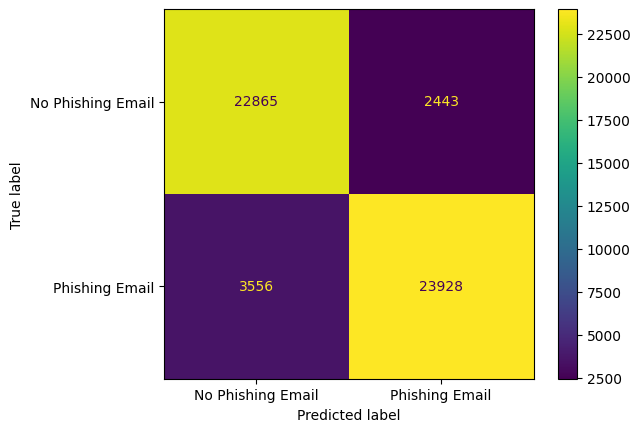

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step
                   precision    recall  f1-score   support

No Phishing Email       0.87      0.89      0.88      6301
   Phishing Email       0.90      0.88      0.89      6896

         accuracy                           0.88     13197
        macro avg       0.88      0.88      0.88     13197
     weighted avg       0.88      0.88      0.88     13197



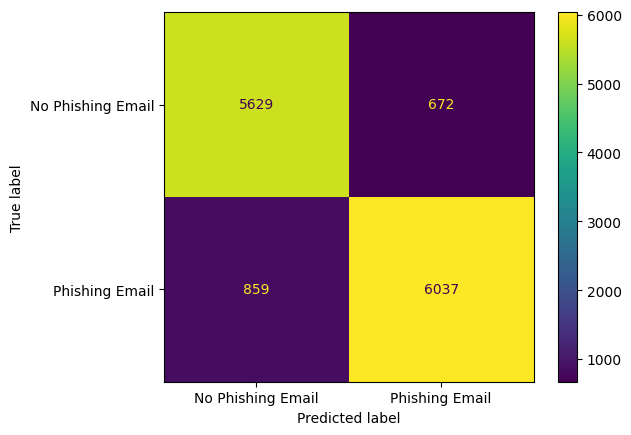

In [5]:
# Loop through all combinations of hyperparameters
for layers in layer_configs:
    for epochs in epochs_list:
        for min_delta in min_deltas:
            for patience in patiences:
                
                # Build the MLP model with specified layer configuration
                model = Sequential()
                
                # Add the input layer and the first hidden layer
                model.add(Dense(layers[0], activation='relu', input_shape=(X_train.shape[1],)))
                
                # Add any additional hidden layers
                for units in layers[1:]:
                    model.add(Dense(units, activation='relu'))
                
                # Add the output layer with sigmoid activation for binary classification
                model.add(Dense(1, activation='sigmoid'))

                # Compile the model with Adam optimizer and binary cross-entropy loss
                model.compile(optimizer=Adam(learning_rate=1e-3),
                              loss='binary_crossentropy',
                              metrics=['accuracy'])

                # Define EarlyStopping to stop training if val_loss doesn't improve
                early_stopping = EarlyStopping(
                    monitor='val_loss',       # Monitor validation loss
                    min_delta=min_delta,      # Minimum change to qualify as improvement
                    patience=patience,        # How many epochs to wait before stopping
                    restore_best_weights=True,# Restore weights from best epoch
                    verbose=1,
                    mode='min'                # Looking for minimum val_loss
                )

                # Define TimeStopping to stop training if it exceeds time limit
                time_stopping = TimeStopping(max_seconds=300)

                # Print current model configuration
                print(f"\nConfig: layers={layers}, epochs={epochs}, "
                      f"min_delta={min_delta}, patience={patience}")

                # Train the model with early stopping and time stopping callbacks
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=epochs,
                    batch_size=32,
                    callbacks=[early_stopping, time_stopping],
                    verbose=2
                )

                # Capture the best validation loss achieved
                val_loss = min(history.history['val_loss'])
                print(f"Finished. Best val_loss={val_loss:.4f}, "
                      f"stopped at epoch {len(history.history['loss'])}\n")

                # Plot learning curves for loss and accuracy
                print("Print History")
                plot_history(history)
                
                # Evaluate on training set and print metrics
                print('Training Evaluation:\n')
                train_scores = eval_classification(model, X_train, y_train,
                                                   name=f'train {layers}-{epochs}-p{patience}-d{min_delta}',
                                                   labels=['No Phishing Email', 'Phishing Email'])

                # Evaluate on validation set and print metrics
                print('Validation Evaluation:\n')
                val_scores = eval_classification(model, X_val, y_val,
                                                 name=f'val {layers}-{epochs}-p{patience}-d{min_delta}',
                                                 labels=['No Phishing Email', 'Phishing Email'])

                # Combine train and validation scores for this run
                scores = pd.concat([train_scores, val_scores])
                all_scores.append(scores)

                # Track the best model based on validation F1 Score
                val_f1 = val_scores.iloc[0]['F1 Score']
                if val_f1 > best_f1:
                    best_f1 = val_f1
                    best_model = model
                    best_history = history
                    best_config = {
                        'layers': layers,
                        'epochs': epochs,
                        'min_delta': min_delta,
                        'patience': patience,
                        'val_f1_score': val_f1
                    }



🏆 Best Model Configuration:
layers: [64]
epochs: 50
min_delta: 0.0
patience: 3
val_f1_score: 0.9625722543352602

📁 Best model saved as 'best_mlp_model.h5'
Results saved to mlp_model_results.csv

📊 Training History of Best Model:


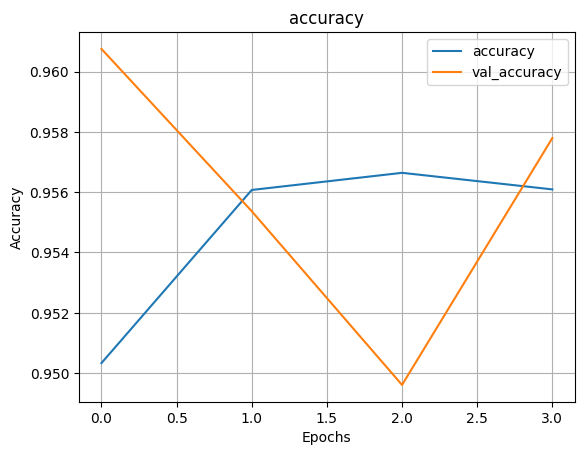

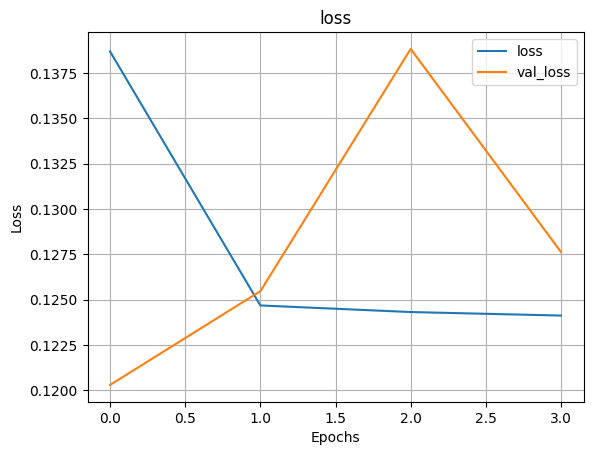

In [6]:
# Print best model config
print("\n🏆 Best Model Configuration:")
for k, v in best_config.items():
    print(f"{k}: {v}")

# Save best model
best_model.save('best_mlp_model.h5')
print("\n📁 Best model saved as 'best_mlp_model.h5'")

# Combine and save all scores
all_results_df = pd.concat(all_scores)
all_results_df.to_csv("mlp_model_results.csv", index=True)
print("Results saved to mlp_model_results.csv")

# Plot training history of the best model
print("\n📊 Training History of Best Model:")
plot_history(best_history)

In [7]:
# Filter only validation results
val_results = all_results_df[all_results_df.index.str.contains("val")]

# Sort by F1 Score in descending order
val_results_sorted = val_results.sort_values(by="F1 Score", ascending=False)

# Display the top results
print("🔝 Top Validation Results by F1 Score:")
display(val_results_sorted.head(10))

🔝 Top Validation Results by F1 Score:


,Accuracy,Precision,Recall,F1 Score,FPR,FNR
val [64]-50-p3-d0.0,0.960749,0.959245,0.965922,0.962572,0.044914,0.034078
val [64]-100-p3-d0.0,0.959612,0.958231,0.964762,0.961486,0.046024,0.035238
val [64]-100-p1-d0.001,0.959536,0.957698,0.965197,0.961433,0.046659,0.034803
val [64]-50-p5-d0.0,0.959309,0.957285,0.965197,0.961225,0.047135,0.034803
val [64]-100-p5-d0.0,0.959157,0.957667,0.964472,0.961058,0.046659,0.035528
val [64]-50-p1-d0.001,0.958779,0.956453,0.965052,0.960733,0.048088,0.034948
val [64]-100-p5-d0.001,0.958475,0.956297,0.964617,0.960439,0.048246,0.035383
val [64]-50-p3-d0.001,0.958475,0.957085,0.963747,0.960405,0.047294,0.036253
val [64]-100-p3-d0.001,0.958400,0.961332,0.958962,0.960145,0.042216,0.041038
val [64]-50-p5-d0.001,0.957642,0.960337,0.958527,0.959431,0.043326,0.041473
